In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

🟢 NB01 — FineZip Setup & Dataset

In [ ]:
#Cell 1 — Kiểm tra GPU
!nvidia-smi

In [ ]:
#Cell 2 — Kiểm tra Python
import sys
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:",
          torch.cuda.get_device_properties(0).total_memory / 1024**3,
          "GB")

In [ ]:
#Cell 3 — Clone FineZip
%cd /kaggle/working

!git clone https://github.com/fazalmittu/finezip.git
%cd /kaggle/working/finezip

!ls -lah

In [ ]:
#Cell 4 — Kiểm tra repository
!find . -maxdepth 2 -type f | head -100

In [ ]:
#Cell 5 — Cài dependency
!pip install -q -r requirements.txt

In [ ]:
!ls

In [ ]:
!sed -n '1,240p' README.md

In [ ]:
!find . -maxdepth 2 -type f | sort

In [ ]:
!sed -n '1,260p' finezip/eval_clean.py

In [ ]:
import importlib.util

packages = [
    "numpy",
    "torch",
    "transformers",
    "bitsandbytes",
    "matplotlib",
    "tqdm"
]

for pkg in packages:
    print(f"{pkg:15} ->", "OK" if importlib.util.find_spec(pkg) else "MISSING")

In [ ]:
!pip install -q bitsandbytes

In [ ]:
#Cell 6 — Kiểm tra package
import torch
import transformers
import peft

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("peft:", peft.__version__)

In [ ]:
#Cell 7 — Tạo thư mục experiment
from pathlib import Path

ROOT = Path("/kaggle/working/finezip_experiment")

for p in [
    "data",
    "compressed",
    "decompressed",
    "results",
    "logs"
]:
    (ROOT / p).mkdir(parents=True, exist_ok=True)

print(ROOT)

In [ ]:
#Cell 8 — Tạo text nhỏ để test
#Trước khi tải enwik8:
text = """
Machine learning is a method of data analysis.
Machine learning can learn patterns from data.
Deep learning is a branch of machine learning.
Neural networks are widely used in machine learning.
""" * 5000

input_file = ROOT / "data" / "test_small.txt"

input_file.write_text(text)

print("File size:",
      input_file.stat().st_size / 1024**2,
      "MB")

In [ ]:
#Cell 9 — Tạo 1 MB dataset
target_size = 1 * 1024 * 1024

base_text = """
Machine learning is a method of data analysis.
Deep learning uses neural networks.
Large language models can predict the next token.
Text compression removes statistical redundancy.
""" 

text = ""

while len(text.encode("utf-8")) < target_size:
    text += base_text

text = text.encode("utf-8")[:target_size].decode(
    "utf-8",
    errors="ignore"
)

one_mb = ROOT / "data" / "text_1mb.txt"
one_mb.write_text(text)

print("Size:",
      one_mb.stat().st_size / 1024**2,
      "MB")

In [ ]:
#Cell 10 — Checkpoint NB01
assert torch.cuda.is_available()
assert input_file.exists()
assert one_mb.exists()

print("NB01 CHECKPOINT: PASS")

🟢 NB02 — FineZip Reproduction

In [ ]:
#Cell 1 — Load configuration
#Đầu tiên xem README/code để biết command chính xác:
%cd /kaggle/working/finezip

!sed -n '1,300p' README.md

In [ ]:
!find . -maxdepth 3 -type f \
    \( -name "*.py" -o -name "*.sh" \) | sort

In [ ]:
# Cell 2 — Inspect FineZip main configuration

%cd /kaggle/working/finezip

!sed -n '250,440p' finezip/eval_clean.py

In [ ]:
# Cell 2 — Test GPT-2 model loading

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "gpt2"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(model_name)

print("Model:", model_name)
print("Parameters:", sum(p.numel() for p in model.parameters()))
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    model = model.to("cuda")
    print("Model device:", next(model.parameters()).device)

print("Tokenizer vocab size:", tokenizer.vocab_size)

In [ ]:
# Cell 2 — Test GPT-2 prediction

text = "The quick brown fox jumps over the"

inputs = tokenizer(text, return_tensors="pt").to("cuda")

with torch.no_grad():
    outputs = model(**inputs)

print("Input shape :", inputs["input_ids"].shape)
print("Logits shape:", outputs.logits.shape)

next_token_logits = outputs.logits[:, -1, :]
next_token = torch.argmax(next_token_logits, dim=-1)

print("Predicted token ID:", next_token.item())
print("Predicted token:", tokenizer.decode(next_token))

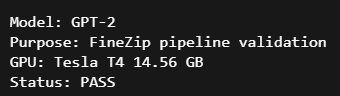

In [ ]:
#Cell 3 — Chuẩn bị file text nhỏ
from pathlib import Path

work_dir = Path("/kaggle/working/finezip_experiment")
data_dir = work_dir / "data"
data_dir.mkdir(parents=True, exist_ok=True)

text = """
The quick brown fox jumps over the lazy dog.
FineZip is a language-model-based text compression system.
This experiment is used to validate the compression pipeline.
GPT-2 is used here for pipeline validation before testing larger models.
Lossless compression means that the original text can be recovered exactly.
"""

input_file = data_dir / "text_test.txt"
input_file.write_text(text.strip() + "\n", encoding="utf-8")

print("Created:", input_file)
print("Size:", input_file.stat().st_size, "bytes")
print("Content:")
print(input_file.read_text(encoding="utf-8"))

In [ ]:
# Verify input file

!ls -lh /kaggle/working/finezip_experiment/data/text_test.txt
!cat /kaggle/working/finezip_experiment/data/text_test.txt


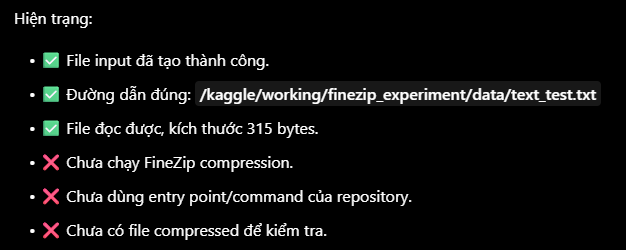

In [ ]:
# Cell 3 — Inspect FineZip compression entry point

%cd /kaggle/working/finezip

!sed -n '413,425p' finezip/eval_clean.py


In [ ]:
# Cell 3 — Prepare FineZip output directories

%cd /kaggle/working/finezip

!mkdir -p zipped
!mkdir -p /kaggle/working/finezip_experiment/results


 nhánh else load GPT-2 lên CPU, trong khi FineZip đưa token lên CUDA.
 Cụ thể hiện tại:

loaded_model = AutoModelForCausalLM.from_pretrained(model)

không có .to("cuda").

Sửa đoạn này

In [ ]:
# Fix GPT-2 device mismatch: move the loaded model to CUDA

from pathlib import Path

path = Path("/kaggle/working/finezip/finezip/eval_clean.py")
src = path.read_text()

old = '''                loaded_model = AutoModelForCausalLM.from_pretrained(model)
                loaded_tokenizer = AutoTokenizer.from_pretrained(model)
                tokenizer_name = model'''

new = '''                loaded_model = AutoModelForCausalLM.from_pretrained(model)
                loaded_model = loaded_model.to("cuda")
                loaded_tokenizer = AutoTokenizer.from_pretrained(model)
                tokenizer_name = model'''

if old in src:
    src = src.replace(old, new)
    path.write_text(src)
    print("✓ Patch applied: GPT-2 will be loaded onto CUDA.")
else:
    print("Target code was not found. No changes made.")


In [ ]:
#Verify
%cd /kaggle/working/finezip

!sed -n '300,310p' finezip/eval_clean.py #Đoạn này xác nhận GPT-2 được chuyển sang CUDA:

In [ ]:
#Bước 1 — Reload module
import importlib
import finezip.eval_clean as eval_clean

importlib.reload(eval_clean)

print("eval_clean reloaded")

In [ ]:
#Tạo thư mục plots
%cd /kaggle/working/finezip

!mkdir -p plots
!mkdir -p zipped

print("plots/ and zipped/ are ready.")


In [ ]:
# Bước 2 — Chạy lại compression
# Cell 3 — Run FineZip compression on the small test file

%cd /kaggle/working/finezip

eval_clean.memory_eval(
    finetuned_models=None,
    original_model_names=["gpt2"],
    context_sizes=[32],
    batch_size=1,
    file_path="/kaggle/working/finezip_experiment/data/text_test.txt",
    save_name="gpt2_test"
)

In [ ]:
#Kiểm tra output compression
%cd /kaggle/working/finezip

!ls -lh zipped/
!ls -lh plots/


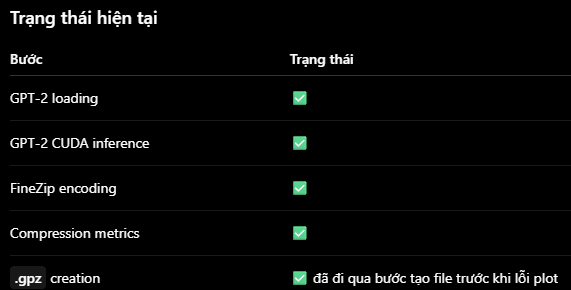

In [ ]:
# Cell 4 — Measure FineZip compression time

import time
import os
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from finezip.eval_clean import ZipModel

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(model_name)
model = model.to("cuda")
model.eval()

zip_model = ZipModel(
    model_name=model_name,
    tokenizer_name=model_name,
    model=model,
    tokenizer=tokenizer,
    finetuned=False,
    context_size=32,
    batch_size=1
)

input_file = "/kaggle/working/finezip_experiment/data/text_test.txt"
output_file = "/kaggle/working/finezip_experiment/gpt2_32_1.gpz"

start = time.perf_counter()

zip_model.zip_file(input_file, output_file)

if torch.cuda.is_available():
    torch.cuda.synchronize()

compress_time = time.perf_counter() - start

print("Compression time:", compress_time, "seconds")
print("Compressed file:", output_file)
print("Compressed size:", os.path.getsize(output_file), "bytes")


In [ ]:
# Inspect the exact FineZip zip/unzip implementation

%cd /kaggle/working/finezip

!sed -n '195,240p' finezip/eval_clean.py


In [ ]:
from pathlib import Path

p = Path("/kaggle/working/finezip_experiment/gpt2_32_1.gpz")

print("Exists:", p.exists())
print("Size:", p.stat().st_size if p.exists() else "N/A")

if p.exists():
    data = p.read_bytes()
    print("First 32 bytes:", data[:32])


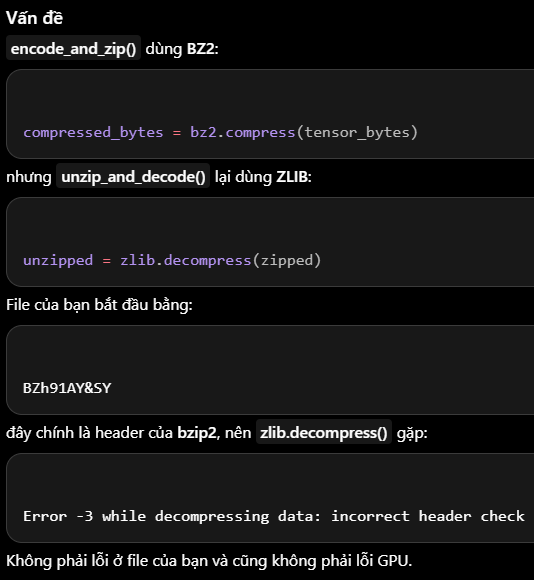

In [ ]:
# Fix FineZip decompression: use bz2 to match encode_and_zip()

from pathlib import Path

path = Path("/kaggle/working/finezip/finezip/eval_clean.py")
src = path.read_text()

old = "unzipped = zlib.decompress(zipped)"
new = "unzipped = bz2.decompress(zipped)"

if old in src:
    src = src.replace(old, new)
    path.write_text(src)
    print("✓ Fixed: zlib.decompress -> bz2.decompress")
else:
    print("Target line not found.")


In [ ]:
%cd /kaggle/working/finezip

!sed -n '210,220p' finezip/eval_clean.py


In [ ]:
#reload module:
import importlib
import finezip.eval_clean as eval_clean

importlib.reload(eval_clean)


In [ ]:
#Quan trọng: zip_model hiện tại được tạo từ class trước khi reload, nên tạo lại ZipModel bằng class mới:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(model_name)
model = model.to("cuda")
model.eval()

zip_model = eval_clean.ZipModel(
    model_name=model_name,
    tokenizer_name=model_name,
    model=model,
    tokenizer=tokenizer,
    finetuned=False,
    context_size=32,
    batch_size=1
)


là warning khi load GPT-2, không phải lỗi, và Cell 2 trước đó đã chạy inference thành công. đã tạo lại zip_model bằng class sau khi sửa bz2.decompress, nên chạy Cell 5:

In [ ]:
# Cell 5 — Decompression + lossless verification

import time
from pathlib import Path

input_file = Path(
    "/kaggle/working/finezip_experiment/data/text_test.txt"
)

compressed_file = Path(
    "/kaggle/working/finezip_experiment/gpt2_32_1.gpz"
)

decoded_file = Path(
    "/kaggle/working/finezip_experiment/data/text_test_decoded.txt"
)

start = time.perf_counter()

zip_model.unzip_file(
    str(compressed_file),
    str(decoded_file)
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

decompress_time = time.perf_counter() - start

print("Decompression time:", decompress_time, "seconds")
print("Decoded file:", decoded_file)
#Nếu chạy thành công, chưa kết luận lossless ngay. Sau đó chạy cell verify:

In [ ]:
# Verify lossless reconstruction

original_text = input_file.read_text(encoding="utf-8")
decoded_text = decoded_file.read_text(encoding="utf-8")

print("Original size :", len(original_text.encode("utf-8")), "bytes")
print("Decoded size  :", len(decoded_text.encode("utf-8")), "bytes")
print("Exact match   :", original_text == decoded_text)

if original_text == decoded_text:
    print("PASS — Lossless decompression verified.")
else:
    print("FAIL — Decoded text differs from original.")


In [ ]:
# Cell 6 — So sánh nội dung original và decoded

print("===== ORIGINAL =====")
print(original_text)

print("\n===== DECODED =====")
print(decoded_text)

print("\n===== repr ORIGINAL =====")
print(repr(original_text))

print("\n===== repr DECODED =====")
print(repr(decoded_text))


In [ ]:
# Find the first difference

from itertools import zip_longest

for i, (a, b) in enumerate(zip_longest(original_text, decoded_text, fillvalue="")):
    if a != b:
        print("First difference at character:", i)
        print("Original:", repr(a))
        print("Decoded :", repr(b))
        print("Original context:", repr(original_text[max(0, i-30):i+50]))
        print("Decoded context :", repr(decoded_text[max(0, i-30):i+50]))
        break
else:
    print("No character difference found.")


In [ ]:
#Bước tiếp theo: kiểm tra encode/decode trực tiếp. kiểm tra trước cả BZ2:
# Cell 7 — Test FineZip encode/decode directly

test_text = original_text

print("Original text:")
print(repr(test_text))

tokens = zip_model.text_to_tokens(test_text)

print("\nToken tensor:")
print("Shape:", tokens.shape)
print("Dtype:", tokens.dtype)
print("First tokens:", tokens.flatten()[:20].tolist())

encoded = zip_model.encode(test_text)

print("\nEncoded:")
print("Type:", type(encoded))
print("Length:", len(encoded))
print("First values:", encoded[:20])

decoded_direct = zip_model.decode(
    torch.tensor(encoded)
)

print("\nDirect decoded text:")
print(repr(decoded_direct))

print("\nDirect exact match:", test_text == decoded_direct)


In [ ]:
#Và kiểm tra dtype/giá trị trước khi BZ2
# Cell 8 — Inspect encode dtype and decode assumptions

encoded_tensor = torch.tensor(encoded)

print("Encoded tensor dtype:", encoded_tensor.dtype)
print("Encoded tensor shape:", encoded_tensor.shape)
print("Min:", encoded_tensor.min().item())
print("Max:", encoded_tensor.max().item())

print("\nDecoder reconstruction dtype:")
import array

arr = array.array("H", encoded_tensor.numpy().tobytes())

reconstructed = torch.tensor(arr)

print("Reconstructed dtype:", reconstructed.dtype)
print("Reconstructed shape:", reconstructed.shape)
print("Same length:", len(encoded_tensor) == len(reconstructed))
print("Same values:", torch.equal(encoded_tensor, reconstructed))


In [ ]:
# Cell 9 — Fix FineZip tensor serialization dtype

from pathlib import Path

path = Path("/kaggle/working/finezip/finezip/eval_clean.py")

src = path.read_text()

old = 'unzipped = array.array("H", unzipped)'
new = 'unzipped = array.array("i", unzipped)'

if old in src:
    src = src.replace(old, new)
    path.write_text(src)
    print("✓ Fixed tensor deserialization: uint16 -> int32")
else:
    print("Target line not found.")


In [ ]:
%cd /kaggle/working/finezip

!sed -n '210,220p' finezip/eval_clean.py

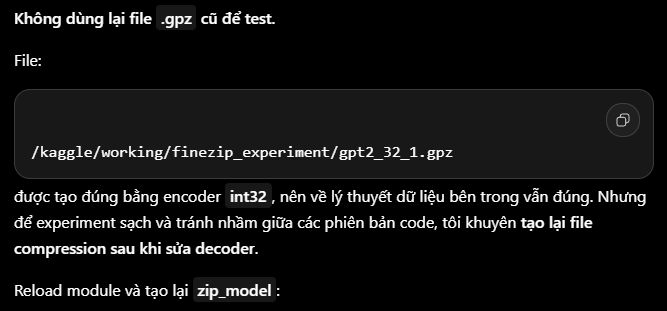

In [ ]:
import importlib
import finezip.eval_clean as eval_clean

importlib.reload(eval_clean)

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(model_name)
model = model.to("cuda")
model.eval()

zip_model = eval_clean.ZipModel(
    model_name=model_name,
    tokenizer_name=model_name,
    model=model,
    tokenizer=tokenizer,
    finetuned=False,
    context_size=32,
    batch_size=1
)
#Sau đó tạo lại .gpz:

In [ ]:
# Re-create compressed file after fixing serialization

input_file = "/kaggle/working/finezip_experiment/data/text_test.txt"
compressed_file = "/kaggle/working/finezip_experiment/gpt2_32_1.gpz"

zip_model.zip_file(
    input_file,
    compressed_file
)

print("Re-created:", compressed_file)


In [ ]:
#Sau đó chạy lại Cell 5
import time
from pathlib import Path

input_file = Path(
    "/kaggle/working/finezip_experiment/data/text_test.txt"
)

compressed_file = Path(
    "/kaggle/working/finezip_experiment/gpt2_32_1.gpz"
)

decoded_file = Path(
    "/kaggle/working/finezip_experiment/data/text_test_decoded.txt"
)

start = time.perf_counter()

zip_model.unzip_file(
    str(compressed_file),
    str(decoded_file)
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

decompress_time = time.perf_counter() - start

print("Decompression time:", decompress_time, "seconds")
print("Decoded file:", decoded_file)


In [ ]:
#verify:
original_text = input_file.read_text(encoding="utf-8")
decoded_text = decoded_file.read_text(encoding="utf-8")

print("Original size :", len(original_text.encode("utf-8")), "bytes")
print("Decoded size  :", len(decoded_text.encode("utf-8")), "bytes")
print("Exact match   :", original_text == decoded_text)

if original_text == decoded_text:
    print("PASS — Lossless decompression verified.")
else:
    print("FAIL — Decoded text differs from original.")


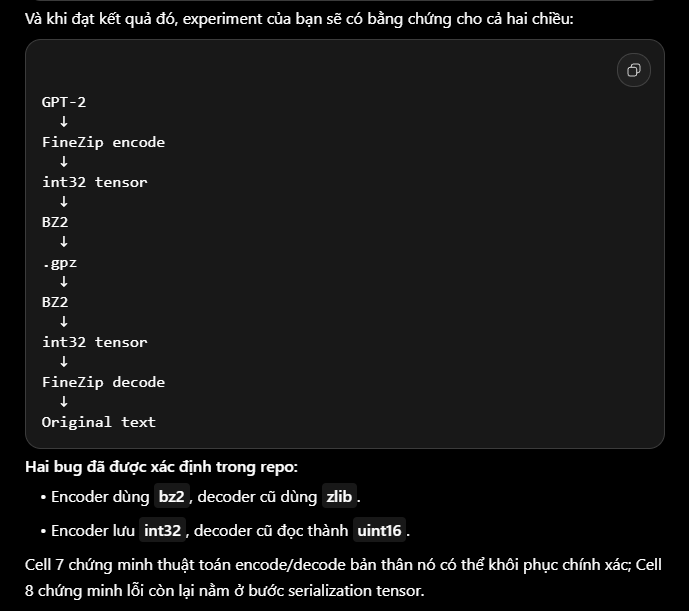

In [ ]:
# Cell 9 — Compression ratio

from pathlib import Path

original_file = Path(
    "/kaggle/working/finezip_experiment/data/text_test.txt"
)

compressed_file = Path(
    "/kaggle/working/finezip_experiment/gpt2_32_1.gpz"
)

original_size = original_file.stat().st_size
compressed_size = compressed_file.stat().st_size

compression_ratio = original_size / compressed_size
compressed_percent = compressed_size / original_size * 100
space_saved = (1 - compressed_size / original_size) * 100

print("Original size     :", original_size, "bytes")
print("Compressed size   :", compressed_size, "bytes")
print("Compression ratio :", compression_ratio)
print("Compressed size % :", compressed_percent, "%")
print("Space saved       :", space_saved, "%")


**Nếu muốn đo peak memory của chính lần compression, nên reset trước khi compression:**

torch.cuda.reset_peak_memory_stats()

**rồi chạy compression, sau đó:**

torch.cuda.synchronize()

print(
    "Peak GPU memory:",
    torch.cuda.max_memory_allocated(0) / 1024**2,
    "MiB"
)

In [ ]:
# Cell 10 — GPU memory measurement

import torch

if torch.cuda.is_available():
    torch.cuda.synchronize()

    allocated = torch.cuda.memory_allocated(0) / 1024**2
    reserved = torch.cuda.memory_reserved(0) / 1024**2
    max_allocated = torch.cuda.max_memory_allocated(0) / 1024**2
    max_reserved = torch.cuda.max_memory_reserved(0) / 1024**2

    print("GPU:", torch.cuda.get_device_name(0))
    print("Current allocated :", allocated, "MiB")
    print("Current reserved  :", reserved, "MiB")
    print("Peak allocated    :", max_allocated, "MiB")
    print("Peak reserved     :", max_reserved, "MiB")
else:
    print("CUDA is not available.")


In [ ]:
# Cell 11 — Save experiment log

import json
from pathlib import Path

log_dir = Path("/kaggle/working/finezip_experiment/logs")
log_dir.mkdir(parents=True, exist_ok=True)

log = {
    "model": "gpt2",
    "purpose": "FineZip pipeline validation",
    "context_size": 32,
    "batch_size": 1,

    "input_file": str(original_file),
    "compressed_file": str(compressed_file),
    "decoded_file": str(decoded_file),

    "original_size_bytes": original_size,
    "compressed_size_bytes": compressed_size,

    "compression_ratio": compression_ratio,

    "compression_time_seconds": 1.1746998789999452,
    "decompression_time_seconds": decompress_time,

    "lossless": original_text == decoded_text,

    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,

    "gpu_peak_memory_mib": (
        torch.cuda.max_memory_allocated(0) / 1024**2
        if torch.cuda.is_available()
        else None
    )
}

log_file = log_dir / "gpt2_test.json"

with open(log_file, "w", encoding="utf-8") as f:
    json.dump(log, f, indent=2)

print("Log saved:", log_file)


In [ ]:
!zip -r /kaggle/working/finezip_experiment.zip /kaggle/working/finezip_experiment

Giai đoạn 2

In [ ]:
#Cell 1 — Tạo baseline_1mb.txt đúng 1,000,000 bytes (Download đúng enwik8 và tạo 1 MB)
from pathlib import Path
import urllib.request

# ====== CONFIG ======
DATA_DIR = Path("/kaggle/working/finezip_experiment/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

ENWIK8 = DATA_DIR / "enwik8"
DST = DATA_DIR / "baseline_1mb.txt"

TARGET_SIZE = 1_000_000

# ====== DOWNLOAD ENWIK8 ======
URL = "http://mattmahoney.net/dc/enwik8.zip"
ZIP_FILE = DATA_DIR / "enwik8.zip"

if not ENWIK8.exists():
    print("Downloading enwik8...")

    urllib.request.urlretrieve(URL, ZIP_FILE)

    print("Downloaded:", ZIP_FILE)
    print("Size:", ZIP_FILE.stat().st_size, "bytes")

    import zipfile

    with zipfile.ZipFile(ZIP_FILE, "r") as z:
        print("Files in archive:", z.namelist())
        z.extract("enwik8", DATA_DIR)

    print("Extracted:", ENWIK8)

else:
    print("enwik8 already exists:", ENWIK8)


# ====== VERIFY ENWIK8 ======
source_size = ENWIK8.stat().st_size

print("\nenwik8 size:", source_size, "bytes")

if source_size < TARGET_SIZE:
    raise ValueError(
        f"enwik8 chỉ có {source_size} bytes, "
        f"không đủ {TARGET_SIZE} bytes."
    )


# ====== CREATE EXACT 1 MB ======
data = ENWIK8.read_bytes()[:TARGET_SIZE]

DST.write_bytes(data)

print("\nCreated:", DST)
print("Size:", DST.stat().st_size, "bytes")

assert DST.stat().st_size == TARGET_SIZE

print("PASS — baseline_1mb.txt is exactly 1,000,000 bytes")


In [ ]:
import hashlib

data = DST.read_bytes()

sha256 = hashlib.sha256(data).hexdigest()

print("File:", DST)
print("Size:", len(data))
print("SHA256:", sha256)


In [ ]:
#Run gzip
import gzip
import time
from pathlib import Path

# ====== CONFIG ======
input_file = DST

gzip_file = BASELINE_DIR / "baseline_1mb.txt.gz"
gzip_decoded = BASELINE_DIR / "baseline_1mb_gzip_decoded.txt"

# ====== COMPRESSION ======
start = time.perf_counter()

with open(input_file, "rb") as f_in:
    with gzip.open(gzip_file, "wb", compresslevel=9) as f_out:
        while True:
            chunk = f_in.read(1024 * 1024)
            if not chunk:
                break
            f_out.write(chunk)

gzip_compression_time = time.perf_counter() - start

# ====== DECOMPRESSION ======
start = time.perf_counter()

with gzip.open(gzip_file, "rb") as f_in:
    with open(gzip_decoded, "wb") as f_out:
        while True:
            chunk = f_in.read(1024 * 1024)
            if not chunk:
                break
            f_out.write(chunk)

gzip_decompression_time = time.perf_counter() - start

# ====== VERIFY LOSSLESS ======
original = input_file.read_bytes()
decoded = gzip_decoded.read_bytes()

gzip_lossless = original == decoded

# ====== METRICS ======
original_size = len(original)
compressed_size = gzip_file.stat().st_size

gzip_ratio = original_size / compressed_size

print("========== GZIP ==========")
print("Original size     :", original_size, "bytes")
print("Compressed size   :", compressed_size, "bytes")
print("Compression ratio :", gzip_ratio)
print("Compression time  :", gzip_compression_time, "seconds")
print("Decompression time:", gzip_decompression_time, "seconds")
print("Decoded size      :", len(decoded), "bytes")
print("Exact match       :", gzip_lossless)

if gzip_lossless:
    print("PASS — Lossless decompression verified.")
else:
    print("FAIL — Decoded file differs from original.")


In [ ]:
#Run BZip2
import bz2
import time
from pathlib import Path

# ====== CONFIG ======
input_file = DST

bz2_file = BASELINE_DIR / "baseline_1mb.txt.bz2"
bz2_decoded = BASELINE_DIR / "baseline_1mb_bz2_decoded.txt"

# ====== COMPRESSION ======
start = time.perf_counter()

with open(input_file, "rb") as f_in:
    data = f_in.read()

compressed_data = bz2.compress(data, compresslevel=9)

with open(bz2_file, "wb") as f_out:
    f_out.write(compressed_data)

bz2_compression_time = time.perf_counter() - start

# ====== DECOMPRESSION ======
start = time.perf_counter()

with open(bz2_file, "rb") as f_in:
    compressed_data = f_in.read()

decoded_data = bz2.decompress(compressed_data)

with open(bz2_decoded, "wb") as f_out:
    f_out.write(decoded_data)

bz2_decompression_time = time.perf_counter() - start

# ====== VERIFY LOSSLESS ======
original = input_file.read_bytes()
decoded = bz2_decoded.read_bytes()

bz2_lossless = original == decoded

# ====== METRICS ======
original_size = len(original)
compressed_size = bz2_file.stat().st_size

bz2_ratio = original_size / compressed_size

print("========== BZIP2 ==========")
print("Original size     :", original_size, "bytes")
print("Compressed size   :", compressed_size, "bytes")
print("Compression ratio :", bz2_ratio)
print("Compression time  :", bz2_compression_time, "seconds")
print("Decompression time:", bz2_decompression_time, "seconds")
print("Decoded size      :", len(decoded), "bytes")
print("Exact match       :", bz2_lossless)

if bz2_lossless:
    print("PASS — Lossless decompression verified.")
else:
    print("FAIL — Decoded file differs from original.")


In [ ]:
#chạy FineZip GPT-2, context 32 trên 1 MB
import sys
import os
import time
import torch
from pathlib import Path

# ====== PATHS ======
FINEZIP_ROOT = Path("/kaggle/working/finezip")
INPUT_FILE = Path(
    "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
)

# FineZip outputs are relative to current working directory
(FINEZIP_ROOT / "zipped").mkdir(parents=True, exist_ok=True)
(FINEZIP_ROOT / "plots").mkdir(parents=True, exist_ok=True)

# ====== MOVE TO FINEZIP REPO ======
os.chdir(FINEZIP_ROOT)

# Make sure Python can import finezip/eval_clean.py
if str(FINEZIP_ROOT) not in sys.path:
    sys.path.insert(0, str(FINEZIP_ROOT))

from finezip.eval_clean import memory_eval

# ====== GPU RESET ======
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "Allocated before:",
        f"{torch.cuda.memory_allocated() / 1024**2:.2f} MiB"
    )
    print(
        "Reserved before:",
        f"{torch.cuda.memory_reserved() / 1024**2:.2f} MiB"
    )

# ====== RUN FINEZIP ======
start = time.perf_counter()

memory_eval(
    finetuned_models=None,
    original_model_names=["gpt2"],
    context_sizes=[32],
    batch_size=1,
    file_path=str(INPUT_FILE),
    save_name="baseline_gpt2_32_1mb"
)

total_time = time.perf_counter() - start

# ====== GPU MEMORY ======
if torch.cuda.is_available():
    torch.cuda.synchronize()

    peak_allocated = (
        torch.cuda.max_memory_allocated() / 1024**2
    )

    current_allocated = (
        torch.cuda.memory_allocated() / 1024**2
    )

    current_reserved = (
        torch.cuda.memory_reserved() / 1024**2
    )

    print("\n========== GPU MEMORY ==========")
    print(f"Peak allocated    : {peak_allocated:.2f} MiB")
    print(f"Current allocated : {current_allocated:.2f} MiB")
    print(f"Current reserved  : {current_reserved:.2f} MiB")

print("\nTotal FineZip runtime:", total_time, "seconds")


In [ ]:
#chạy Cell decompress + Exact Match
from pathlib import Path
import time

# ====== FILES ======
finezip_file = Path(
    "/kaggle/working/finezip/zipped/gpt2_32_1.gpz"
)

finezip_decoded = Path(
    "/kaggle/working/finezip_experiment/data/baseline_1mb_finezip_decoded.txt"
)

input_file = Path(
    "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
)

print("FineZip file:", finezip_file)
print("Exists:", finezip_file.exists())

if not finezip_file.exists():
    raise FileNotFoundError(
        f"Không tìm thấy: {finezip_file}"
    )

# ====== IMPORT ZIPMODEL ======
from finezip.eval_clean import ZipModel
from transformers import AutoTokenizer, AutoModelForCausalLM

import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading GPT-2...")

tokenizer = AutoTokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained("gpt2")
model = model.to(device)
model.eval()

zip_model = ZipModel(
    model_name="gpt2",
    tokenizer_name="gpt2",
    model=model,
    tokenizer=tokenizer,
    finetuned=False,
    context_size=32,
    batch_size=1
)

# ====== DECOMPRESSION ======
print("\nStarting FineZip decompression...")

start = time.perf_counter()

zip_model.unzip_file(
    str(finezip_file),
    str(finezip_decoded)
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

decompression_time = time.perf_counter() - start

print("Decompression time:", decompression_time, "seconds")

# ====== VERIFY LOSSLESS ======
original = input_file.read_bytes()
decoded = finezip_decoded.read_bytes()

print("\n========== FINEZIP VERIFY ==========")
print("Original size :", len(original), "bytes")
print("Decoded size  :", len(decoded), "bytes")
print("Exact match   :", original == decoded)

if original == decoded:
    print("PASS — Lossless decompression verified.")
else:
    print("FAIL — Decoded file differs from original.")


In [ ]:
#compressed size + ratio
from pathlib import Path

finezip_file = Path(
    "/kaggle/working/finezip/zipped/gpt2_32_1.gpz"
)

original_size = Path(
    "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
).stat().st_size

compressed_size = finezip_file.stat().st_size

compression_ratio = original_size / compressed_size
compressed_percent = compressed_size / original_size * 100
space_saved = (1 - compressed_size / original_size) * 100

print("========== FINEZIP SIZE ==========")
print("Original size     :", original_size, "bytes")
print("Compressed size   :", compressed_size, "bytes")
print("Compression ratio :", compression_ratio)
print("Compressed %      :", compressed_percent, "%")
print("Space saved       :", space_saved, "%")

assert original_size == 1_000_000
assert compressed_size > 0

print("\nPASS — compressed file size verified.")


In [ ]:
#check repo có implementation/reference nào liên quan đến LLMZip hay không.
from pathlib import Path

ROOT = Path("/kaggle/working")

print("Searching for LLMZip-related files...\n")

patterns = [
    "*llmzip*",
    "*LLMZip*",
    "*arithmetic*",
    "*compress*",
    "*encode*"
]

found = set()

for pattern in patterns:
    for p in ROOT.rglob(pattern):
        if p.is_file():
            found.add(p)

for p in sorted(found):
    print(p)


hiện tại repo không có sẵn implementation LLMZip. File:

/kaggle/working/finezip/AC/arithmeticcoding.py

chỉ là module Arithmetic Coding của repo FineZip, chưa đủ để kết luận đó là LLMZip.

Vì vậy đừng chạy LLMZip-lite ngay. Ta cần kiểm tra API của arithmeticcoding.py trước, để xây baseline LLMZip-lite đúng cách và tránh nhầm với FineZip hiện tại.

In [ ]:
#đọc arithmeticcoding.py
from pathlib import Path

AC_FILE = Path("/kaggle/working/finezip/AC/arithmeticcoding.py")

print("=" * 80)
print("FILE:", AC_FILE)
print("=" * 80)

with open(AC_FILE, "r", encoding="utf-8") as f:
    code = f.read()

print(code)


 file /kaggle/working/finezip/AC/arithmeticcoding.py không phải LLMZip implementation hoàn chỉnh. Nó chỉ là thư viện Arithmetic Coding, và FineZip hiện tại cũng không gọi trực tiếp phần này trong eval_clean.py mà đang lưu rank rồi dùng bz2.

In [ ]:
#kiểm tra repo có code nào dùng ArithmeticEncoder/ArithmeticDecoder, để tránh tự viết lại LLMZip không cần thiết.
import os
from pathlib import Path

ROOT = Path("/kaggle/working/finezip")

print("Searching for Arithmetic Coding usage...\n")

keywords = [
    "ArithmeticEncoder",
    "ArithmeticDecoder",
    "BitOutputStream",
    "BitInputStream",
]

for pyfile in ROOT.rglob("*.py"):
    try:
        text = pyfile.read_text(errors="ignore")
    except:
        continue

    matches = [k for k in keywords if k in text]

    if matches:
        print("=" * 80)
        print(pyfile)
        print("Found:", matches)

        for i, line in enumerate(text.splitlines(), 1):
            if any(k in line for k in keywords):
                print(f"{i}: {line}")


In [ ]:
#đọc toàn bộ eval_ac.py
from pathlib import Path

AC_FILE = Path("/kaggle/working/finezip/AC/eval_ac.py")

print("=" * 80)
print(f"FILE: {AC_FILE}")
print("=" * 80)

print(AC_FILE.read_text())


In [ ]:
#chạy LLMZip-lite trên 1 MB
#Trước hết tạo output directory:
from pathlib import Path
import shutil

LLMZIP_DIR = Path("/kaggle/working/finezip_experiment/llmzip_lite_1mb")

if LLMZIP_DIR.exists():
    shutil.rmtree(LLMZIP_DIR)

LLMZIP_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", LLMZIP_DIR)


In [ ]:
# chạy encoder/decoder trực tiếp bằng eval_ac.py. (chạy LLMZip-lite GPT-2, context=32)
import sys
import os
import time
import json
import torch

# Cho phép eval_ac.py import arithmeticcoding.py
sys.path.insert(0, "/kaggle/working/finezip/AC")

from eval_ac import (
    AC_Encode,
    AC_Decode,
    text_to_tokens,
    verify_text
)
from transformers import AutoTokenizer, AutoModelForCausalLM


# ============================================================
# CONFIG
# ============================================================

MODEL_NAME = "gpt2"
INPUT_FILE = "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
OUTPUT_DIR = "/kaggle/working/finezip_experiment/llmzip_lite_1mb"

BATCH_SIZE = 1
CONTEXT_SIZE = 32

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("Input:", INPUT_FILE)
print("Output:", OUTPUT_DIR)
print("Batch size:", BATCH_SIZE)
print("Context size:", CONTEXT_SIZE)


# ============================================================
# LOAD MODEL
# ============================================================

print("\nLoading GPT-2...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model = model.to(DEVICE)
model.eval()

print("Model loaded.")
print("Parameters:", sum(p.numel() for p in model.parameters()))


# ============================================================
# READ INPUT
# ============================================================

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    text_input = f.read()

original_size = os.path.getsize(INPUT_FILE)

print("\nOriginal size:", original_size, "bytes")
print("Characters read:", len(text_input))


# ============================================================
# TOKENIZE
# ============================================================

tokens_full = text_to_tokens(tokenizer, text_input)

print("Token count:", tokens_full.numel())


# ============================================================
# GPU MEMORY RESET
# ============================================================

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    print("\nGPU memory before:")
    print(
        f"Allocated: {torch.cuda.memory_allocated()/1024**2:.2f} MiB"
    )
    print(
        f"Reserved : {torch.cuda.memory_reserved()/1024**2:.2f} MiB"
    )


# ============================================================
# ENCODE
# ============================================================

encoder = AC_Encode(
    model=model,
    tokenizer=tokenizer,
    compressed_file_name=INPUT_FILE,
    output_dir=OUTPUT_DIR,
    device=DEVICE,
    batch_size=BATCH_SIZE,
    window_size=CONTEXT_SIZE
)

print("\n========== LLMZIP-LITE ENCODING ==========")

start = time.perf_counter()

total_length, pad_len, vocab_size = encoder.encode_from_tokens(
    tokens_full
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

compression_time = time.perf_counter() - start

print("\nCompression finished.")
print("Compression time:", compression_time, "seconds")


# ============================================================
# COMPRESSED SIZE
# ============================================================

compressed_size = 0

for i in range(BATCH_SIZE):
    ac_file = os.path.join(
        OUTPUT_DIR,
        f"{i}_AC.txt"
    )

    size = os.path.getsize(ac_file)
    compressed_size += size

    print(
        f"AC stream {i}: {size} bytes"
    )


compression_ratio = original_size / compressed_size


print("\n========== LLMZIP-LITE SIZE ==========")
print("Original size   :", original_size)
print("Compressed size :", compressed_size)
print("Compression ratio:", compression_ratio)
print(
    "Compressed %    :",
    compressed_size / original_size * 100
)
print(
    "Space saved %   :",
    (1 - compressed_size / original_size) * 100
)


# ============================================================
# GPU MEMORY
# ============================================================

if torch.cuda.is_available():
    peak_allocated = torch.cuda.max_memory_allocated() / 1024**2
    peak_reserved = torch.cuda.max_memory_reserved() / 1024**2

    print("\n========== GPU MEMORY ==========")
    print(f"Peak allocated : {peak_allocated:.2f} MiB")
    print(f"Peak reserved  : {peak_reserved:.2f} MiB")
else:
    peak_allocated = None
    peak_reserved = None


# ============================================================
# DECODE
# ============================================================

print("\n========== LLMZIP-LITE DECODING ==========")

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

decoder = AC_Decode(
    model=model,
    tokenizer=tokenizer,
    device=DEVICE,
    output_dir=OUTPUT_DIR,
    batch_size=BATCH_SIZE,
    window_size=CONTEXT_SIZE
)

start = time.perf_counter()

decoded_text = decoder.decode_AC(
    total_length=total_length,
    pad_len=pad_len,
    vocab_size=vocab_size
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

decompression_time = time.perf_counter() - start

print("\nDecompression time:", decompression_time, "seconds")


# ============================================================
# VERIFY LOSSLESS
# ============================================================

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    original_text = f.read()

decoded_size = len(decoded_text.encode("utf-8"))
lossless = original_text == decoded_text

print("\n========== LLMZIP-LITE VERIFY ==========")
print("Original bytes :", original_size)
print("Decoded bytes  :", decoded_size)
print("Exact match    :", lossless)

if lossless:
    print("PASS — Lossless decompression verified.")
else:
    print("FAIL — Decoded text does not exactly match input.")


# ============================================================
# SAVE DECODED FILE
# ============================================================

decoded_file = os.path.join(
    OUTPUT_DIR,
    "baseline_1mb_decoded.txt"
)

with open(decoded_file, "w", encoding="utf-8") as f:
    f.write(decoded_text)

print("Decoded file:", decoded_file)


# ============================================================
# SAVE METRICS
# ============================================================

results = {
    "method": "LLMZip-lite",
    "model": MODEL_NAME,
    "context": CONTEXT_SIZE,
    "batch_size": BATCH_SIZE,
    "original_bytes": original_size,
    "compressed_bytes": compressed_size,
    "compression_ratio": compression_ratio,
    "compression_time_seconds": compression_time,
    "decompression_time_seconds": decompression_time,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "peak_gpu_allocated_mib_encode": peak_allocated,
    "peak_gpu_reserved_mib_encode": peak_reserved,
    "lossless": lossless
}

metrics_file = os.path.join(
    OUTPUT_DIR,
    "llmzip_lite_results.json"
)

with open(metrics_file, "w") as f:
    json.dump(results, f, indent=2)

print("\nSaved metrics:", metrics_file)


In [ ]:
#tạo baseline_results.csv
import csv
from pathlib import Path

BASE_DIR = Path("/kaggle/working/finezip_experiment")

results = [
    {
        "Method": "gzip",
        "Model": "-",
        "Context": "-",
        "Original": 1_000_000,
        "Compressed": 355_808,
        "Ratio": 2.8105045417753396,
        "Comp. Time": 0.06957770400003938,
        "Decomp. Time": 0.0063651620000655385,
        "GPU Memory": "-",
        "Lossless": True
    },
    {
        "Method": "bzip2",
        "Model": "-",
        "Context": "-",
        "Original": 1_000_000,
        "Compressed": 281_323,
        "Ratio": 3.554632930830398,
        "Comp. Time": 0.09505659300020852,
        "Decomp. Time": 0.04075199299995802,
        "GPU Memory": "-",
        "Lossless": True
    },
    {
        "Method": "LLMZip-lite",
        "Model": "GPT-2",
        "Context": 32,
        "Original": 1_000_000,
        "Compressed": 186_860,
        "Ratio": 5.351600128438403,
        "Comp. Time": 2905.9290929399995,
        "Decomp. Time": 2851.3187257579993,
        "GPU Memory": 995.75,
        "Lossless": True
    },
    {
        "Method": "FineZip",
        "Model": "GPT-2",
        "Context": 32,
        "Original": 1_000_000,
        "Compressed": 293_093,
        "Ratio": 3.4118863295950432,
        "Comp. Time": 2740.088533996,
        "Decomp. Time": 2761.864154029,
        "GPU Memory": 993.43,
        "Lossless": True
    }
]

csv_file = BASE_DIR / "baseline_results.csv"

fieldnames = [
    "Method",
    "Model",
    "Context",
    "Original",
    "Compressed",
    "Ratio",
    "Comp. Time",
    "Decomp. Time",
    "GPU Memory",
    "Lossless"
]

with open(csv_file, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(results)

print("Created:", csv_file)
print()

# Verify
with open(csv_file, "r") as f:
    print(f.read())


**Giai đoạn 3** cho cả FineZip và LLMZip-Lite, chạy 5 context size cho cùng một file 1 MB và cùng GPT-2, rồi mới so sánh hai phương pháp.

In [ ]:
from pathlib import Path
import torch
import os

INPUT_FILE = Path("/kaggle/working/finezip_experiment/data/baseline_1mb.txt")

assert INPUT_FILE.exists(), f"Không tìm thấy: {INPUT_FILE}"
assert INPUT_FILE.stat().st_size == 1_000_000, "Input không đúng 1,000,000 bytes"

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Input:", INPUT_FILE)
print("Size:", INPUT_FILE.stat().st_size, "bytes")


**Phần A — FineZip**

In [ ]:
#Cell 2 — Chạy FineZip với 5 context size (gọi trực tiếp memory_eval() của FineZip.)
import sys
from pathlib import Path

FINEZIP_ROOT = Path("/kaggle/working/finezip")

if str(FINEZIP_ROOT) not in sys.path:
    sys.path.insert(0, str(FINEZIP_ROOT))

from finezip.eval_clean import memory_eval

FINEZIP_INPUT = "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"

FINEZIP_CONTEXTS = [32, 64, 128, 256, 512]

print("========== FINEZIP EXPERIMENT ==========")
print("Input:", FINEZIP_INPUT)
print("Context sizes:", FINEZIP_CONTEXTS)
print("Model: GPT-2")
print()

memory_eval(
    finetuned_models=None,
    original_model_names=["gpt2"],
    context_sizes=FINEZIP_CONTEXTS,
    batch_size=64,
    file_path=FINEZIP_INPUT,
    save_name="finezip_context_experiment"
)


In [ ]:
#Cell 3 — Tạo thư mục output FineZip
from pathlib import Path

Path("/kaggle/working/finezip/zipped").mkdir(parents=True, exist_ok=True)
Path("/kaggle/working/finezip/plots").mkdir(parents=True, exist_ok=True)

print("FineZip output directories ready.")


**Phần B** — FineZip: lấy kết quả thành bảng
memory_eval() đã in ra compression ratio, nhưng nó chưa lưu toàn bộ compression/decompression time theo từng context theo format thuận tiện.

Lấy kích thước các .gpz sau khi chạy.

In [ ]:
#Cell 4 — Đọc size FineZip
from pathlib import Path

FINEZIP_ZIPPED = Path("/kaggle/working/finezip/zipped")

finezip_results = []

for context in [32, 64, 128, 256, 512]:
    file_path = FINEZIP_ZIPPED / f"gpt2_{context}_64.gpz"

    if file_path.exists():
        compressed_size = file_path.stat().st_size
        original_size = 1_000_000

        finezip_results.append({
            "Method": "FineZip",
            "Context": context,
            "Original Size": original_size,
            "Compressed Size": compressed_size,
            "Compression Ratio": original_size / compressed_size,
            "Compressed %": compressed_size / original_size * 100
        })
    else:
        print("MISSING:", file_path)

finezip_results


**Phần C **— LLMZip-Lite

In [ ]:
#Cell 5 — Kiểm tra các file FineZip và lấy thời gian encode/decode
from pathlib import Path
import json

FINEZIP_ROOT = Path("/kaggle/working/finezip")

print("========== SEARCH FINEZIP METRICS ==========")

for context in [32, 64, 128, 256, 512]:
    print(f"\n--- Context {context} ---")
    
    # Tìm các file metrics/json liên quan
    matches = list(FINEZIP_ROOT.rglob(f"*{context}*"))
    
    for p in matches[:20]:
        print(p)


In [ ]:
#Cell 6 — Kiểm tra memory_eval() có lưu thời gian không
import inspect
from finezip.eval_clean import memory_eval

print(inspect.getsource(memory_eval))


thời gian encode của FineZip đã được lưu ở dòng cuối mỗi file .txt. memory_eval() chưa lưu decode time, nên hiện tại ta lấy được encode time trước.

In [ ]:
#Cell 7 — Lấy encode time + size + compression ratio của FineZip
from pathlib import Path
import os

FINEZIP_ZIPPED = Path("/kaggle/working/finezip/zipped")
ORIGINAL_SIZE = 1_000_000
CONTEXTS = [32, 64, 128, 256, 512]
BATCH_SIZE = 64

finezip_results = []

for context in CONTEXTS:
    gpz_file = FINEZIP_ZIPPED / f"gpt2_{context}_{BATCH_SIZE}.gpz"
    txt_file = FINEZIP_ZIPPED / f"gpt2_{context}_{BATCH_SIZE}.txt"

    if not gpz_file.exists():
        print("MISSING GPZ:", gpz_file)
        continue

    if not txt_file.exists():
        print("MISSING TXT:", txt_file)
        continue

    # File size
    compressed_size = gpz_file.stat().st_size

    # Last line = encode time
    with open(txt_file, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    encode_time = float(lines[-1])

    finezip_results.append({
        "Method": "FineZip",
        "Context": context,
        "Original Size": ORIGINAL_SIZE,
        "Compressed Size": compressed_size,
        "Compression Ratio": ORIGINAL_SIZE / compressed_size,
        "Compressed %": compressed_size / ORIGINAL_SIZE * 100,
        "Encode Time (s)": encode_time
    })

import pandas as pd

finezip_df = pd.DataFrame(finezip_results)

print("========== FINEZIP RESULTS ==========")
display(finezip_df)


In [ ]:
#Cell 8 — kiểm tra cấu trúc code LLMZip-Lite
from pathlib import Path

ROOT = Path("/kaggle/working/finezip_experiment")

print("========== SEARCH LLMZIP-LITE FILES ==========")

for p in ROOT.rglob("*"):
    if p.is_file() and (
        "llmzip" in p.name.lower()
        or "lite" in p.name.lower()
    ):
        print(p)


In [ ]:
#Cell 9 — tìm notebook
from pathlib import Path

SEARCH_ROOTS = [
    Path("/kaggle/working"),
]

print("========== SEARCH NOTEBOOKS ==========")

for root in SEARCH_ROOTS:
    for p in root.rglob("*.ipynb"):
        print(p)

In [ ]:
#Cell 10 — tìm hàm/class LLMZip-Lite đang tồn tại
print("========== SEARCH LOADED LLMZIP OBJECTS ==========")

matches = []

for name in list(globals().keys()):
    try:
        obj = globals()[name]
        name_lower = name.lower()

        if "llmzip" in name_lower or "lite" in name_lower:
            matches.append((name, type(obj), obj))
    except Exception:
        pass

if matches:
    for name, obj_type, obj in matches:
        print(f"{name:40s} | {obj_type}")
else:
    print("No LLMZip-Lite objects found in current kernel.")


In [ ]:
from pathlib import Path

SEARCH_ROOTS = [
    Path("/kaggle/working/finezip_experiment"),
    Path("/kaggle/working/finezip"),
]

keywords = [
    "LLMZIP",
    "llmzip",
    "AC_Encode",
    "ArithmeticEncoder",
    "context_size",
    "window_size",
]

print("=" * 70)
print("SEARCH PYTHON FILES FOR LLMZIP PIPELINE")
print("=" * 70)

found = set()

for root in SEARCH_ROOTS:
    if not root.exists():
        continue

    for pyfile in root.rglob("*.py"):
        try:
            text = pyfile.read_text(
                encoding="utf-8",
                errors="ignore"
            )
        except Exception:
            continue

        matched = [k for k in keywords if k in text]

        if matched:
            found.add(pyfile)
            print(f"\n{pyfile}")
            print("Matched:", matched)

print("\n" + "=" * 70)
print("TOTAL FILES:", len(found))
print("=" * 70)


 pipeline LLMZip-Lite chính là /kaggle/working/finezip/AC/eval_ac.py mà bạn đã gửi ở trên. Ta không cần tìm thêm.

Bây giờ chạy context = 32 trước. Cell dưới đây gọi trực tiếp eval_ac.py, dùng GPT-2 + cùng file 1 MB + batch 1, và lưu riêng kết quả.

In [ ]:
import os
import json
import subprocess
from pathlib import Path

# ============================================================
# LLMZIP-LITE — CONTEXT 32
# ============================================================

INPUT_FILE = "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
OUTPUT_DIR = "/kaggle/working/finezip_experiment/llmzip_lite_ctx32"

MODEL = "gpt2"
TOKENIZER = "gpt2"

BATCH_SIZE = 1
CONTEXT_SIZE = 32

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("LLMZIP-LITE — CONTEXT 32")
print("=" * 70)
print("Model       :", MODEL)
print("Input       :", INPUT_FILE)
print("Output      :", OUTPUT_DIR)
print("Batch size  :", BATCH_SIZE)
print("Context size:", CONTEXT_SIZE)
print()

cmd = [
    "python",
    "/kaggle/working/finezip/AC/eval_ac.py",

    "--model", MODEL,
    "--tokenizer", TOKENIZER,

    "--batch_size", str(BATCH_SIZE),
    "--context_size", str(CONTEXT_SIZE),

    "--input_file", INPUT_FILE,
    "--AC_output_dir", OUTPUT_DIR,

    "--encode_decode", "1",
]

print("Running:")
print(" ".join(cmd))
print()

result = subprocess.run(
    cmd,
    capture_output=False,
    text=True
)

print()
print("=" * 70)
print("PROCESS RETURN CODE:", result.returncode)
print("=" * 70)

# Kiểm tra metrics
metrics_file = Path(OUTPUT_DIR) / "metrics.json"

if metrics_file.exists():
    print("\n========== METRICS ==========")
    with open(metrics_file, "r") as f:
        metrics = json.load(f)

    print(json.dumps(metrics, indent=2))
else:
    print("\nWARNING: metrics.json chưa được tạo.")


In [ ]:
#LLMZip-Lite Context 64
import os
import json
import subprocess
from pathlib import Path

# ============================================================
# LLMZIP-LITE — CONTEXT 64
# ============================================================

INPUT_FILE = "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
OUTPUT_DIR = "/kaggle/working/finezip_experiment/llmzip_lite_ctx64"

MODEL = "gpt2"
TOKENIZER = "gpt2"

BATCH_SIZE = 1
CONTEXT_SIZE = 64

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("LLMZIP-LITE — CONTEXT 64")
print("=" * 70)
print("Model       :", MODEL)
print("Input       :", INPUT_FILE)
print("Output      :", OUTPUT_DIR)
print("Batch size  :", BATCH_SIZE)
print("Context size:", CONTEXT_SIZE)
print()

cmd = [
    "python",
    "/kaggle/working/finezip/AC/eval_ac.py",
    "--model", MODEL,
    "--tokenizer", TOKENIZER,
    "--batch_size", str(BATCH_SIZE),
    "--context_size", str(CONTEXT_SIZE),
    "--input_file", INPUT_FILE,
    "--AC_output_dir", OUTPUT_DIR,
    "--encode_decode", "1",
]

print("Running:")
print(" ".join(cmd))
print()

result = subprocess.run(cmd, text=True)

print()
print("=" * 70)
print("PROCESS RETURN CODE:", result.returncode)
print("=" * 70)

metrics_file = Path(OUTPUT_DIR) / "metrics.json"

if metrics_file.exists():
    print("\n========== METRICS ==========")

    with open(metrics_file, "r") as f:
        metrics = json.load(f)

    print(json.dumps(metrics, indent=2))
else:
    print("\nWARNING: metrics.json chưa được tạo.")


In [ ]:
import os
import json
import subprocess
from pathlib import Path

# ============================================================
# LLMZIP-LITE — CONTEXT 128
# ============================================================

INPUT_FILE = "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
OUTPUT_DIR = "/kaggle/working/finezip_experiment/llmzip_lite_ctx128"

MODEL = "gpt2"
TOKENIZER = "gpt2"

BATCH_SIZE = 1
CONTEXT_SIZE = 128

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("LLMZIP-LITE — CONTEXT 128")
print("=" * 70)
print("Model       :", MODEL)
print("Input       :", INPUT_FILE)
print("Output      :", OUTPUT_DIR)
print("Batch size  :", BATCH_SIZE)
print("Context size:", CONTEXT_SIZE)
print()

cmd = [
    "python",
    "/kaggle/working/finezip/AC/eval_ac.py",
    "--model", MODEL,
    "--tokenizer", TOKENIZER,
    "--batch_size", str(BATCH_SIZE),
    "--context_size", str(CONTEXT_SIZE),
    "--input_file", INPUT_FILE,
    "--AC_output_dir", OUTPUT_DIR,
    "--encode_decode", "1",
]

print("Running:")
print(" ".join(cmd))
print()

result = subprocess.run(cmd, text=True)

print()
print("=" * 70)
print("PROCESS RETURN CODE:", result.returncode)
print("=" * 70)

metrics_file = Path(OUTPUT_DIR) / "metrics.json"

if metrics_file.exists():
    print("\n========== METRICS ==========")

    with open(metrics_file, "r") as f:
        metrics = json.load(f)

    print(json.dumps(metrics, indent=2))
else:
    print("\nWARNING: metrics.json chưa được tạo.")


In [ ]:
import os
import json
import subprocess
from pathlib import Path

# ============================================================
# LLMZIP-LITE — CONTEXT 256
# ============================================================

INPUT_FILE = "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
OUTPUT_DIR = "/kaggle/working/finezip_experiment/llmzip_lite_ctx256"

MODEL = "gpt2"
TOKENIZER = "gpt2"

BATCH_SIZE = 1
CONTEXT_SIZE = 256

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("LLMZIP-LITE — CONTEXT 256")
print("=" * 70)
print("Model       :", MODEL)
print("Input       :", INPUT_FILE)
print("Output      :", OUTPUT_DIR)
print("Batch size  :", BATCH_SIZE)
print("Context size:", CONTEXT_SIZE)
print()

cmd = [
    "python",
    "/kaggle/working/finezip/AC/eval_ac.py",
    "--model", MODEL,
    "--tokenizer", TOKENIZER,
    "--batch_size", str(BATCH_SIZE),
    "--context_size", str(CONTEXT_SIZE),
    "--input_file", INPUT_FILE,
    "--AC_output_dir", OUTPUT_DIR,
    "--encode_decode", "1",
]

print("Running:")
print(" ".join(cmd))
print()

result = subprocess.run(cmd, text=True)

print()
print("=" * 70)
print("PROCESS RETURN CODE:", result.returncode)
print("=" * 70)

metrics_file = Path(OUTPUT_DIR) / "metrics.json"

if metrics_file.exists():
    print("\n========== METRICS ==========")

    with open(metrics_file, "r") as f:
        metrics = json.load(f)

    print(json.dumps(metrics, indent=2))
else:
    print("\nWARNING: metrics.json chưa được tạo.")


In [ ]:
import os
import json
import subprocess
from pathlib import Path

# ============================================================
# LLMZIP-LITE — CONTEXT 512
# ============================================================

INPUT_FILE = "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
OUTPUT_DIR = "/kaggle/working/finezip_experiment/llmzip_lite_ctx512"

MODEL = "gpt2"
TOKENIZER = "gpt2"

BATCH_SIZE = 1
CONTEXT_SIZE = 512

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("LLMZIP-LITE — CONTEXT 512")
print("=" * 70)
print("Model       :", MODEL)
print("Input       :", INPUT_FILE)
print("Output      :", OUTPUT_DIR)
print("Batch size  :", BATCH_SIZE)
print("Context size:", CONTEXT_SIZE)
print()

cmd = [
    "python",
    "/kaggle/working/finezip/AC/eval_ac.py",
    "--model", MODEL,
    "--tokenizer", TOKENIZER,
    "--batch_size", str(BATCH_SIZE),
    "--context_size", str(CONTEXT_SIZE),
    "--input_file", INPUT_FILE,
    "--AC_output_dir", OUTPUT_DIR,
    "--encode_decode", "1",
]

print("Running:")
print(" ".join(cmd))
print()

result = subprocess.run(cmd, text=True)

print()
print("=" * 70)
print("PROCESS RETURN CODE:", result.returncode)
print("=" * 70)

metrics_file = Path(OUTPUT_DIR) / "metrics.json"

if metrics_file.exists():
    print("\n========== METRICS ==========")

    with open(metrics_file, "r") as f:
        metrics = json.load(f)

    print(json.dumps(metrics, indent=2))
else:
    print("\nWARNING: metrics.json chưa được tạo.")

In [ ]:
# ============================================================
# VERIFY: Does eval_ac.py actually limit GPT-2 input
# to the specified context_size?
# ============================================================

from pathlib import Path
import re

FILE = Path("/kaggle/working/finezip/AC/eval_ac.py")

print("=" * 70)
print("VERIFY eval_ac.py CONTEXT HANDLING")
print("=" * 70)
print("File:", FILE)
print("Exists:", FILE.exists())

if not FILE.exists():
    raise FileNotFoundError(FILE)

lines = FILE.read_text(errors="ignore").splitlines()

# ------------------------------------------------------------
# 1. Show every occurrence of context_size
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("1. OCCURRENCES OF context_size")
print("=" * 70)

matches = []
for i, line in enumerate(lines, 1):
    if "context_size" in line.lower():
        matches.append(i)
        start = max(1, i - 4)
        end = min(len(lines), i + 8)

        print(f"\n--- line {i} ---")
        for j in range(start, end + 1):
            print(f"{j:4}: {lines[j-1]}")

# ------------------------------------------------------------
# 2. Find model calls
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("2. POSSIBLE GPT-2 MODEL CALLS")
print("=" * 70)

keywords = [
    "model(",
    "model.generate",
    "input_ids",
    "attention_mask",
    "logits",
    "outputs",
    "forward(",
]

model_matches = []

for i, line in enumerate(lines, 1):
    if any(k.lower() in line.lower() for k in keywords):
        model_matches.append(i)
        print(f"{i:4}: {line}")

# ------------------------------------------------------------
# 3. Search for actual slicing/window operations
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("3. POSSIBLE CONTEXT WINDOW / SLICING OPERATIONS")
print("=" * 70)

patterns = [
    r"\[.*context_size.*\]",
    r"\[.*ctx.*\]",
    r"range\(.*context",
    r"range\(.*ctx",
    r"chunk",
    r"window",
    r"unfold",
    r"split",
    r"reshape",
    r"view",
    r"[:,].*context",
]

for i, line in enumerate(lines, 1):
    if any(re.search(p, line, re.I) for p in patterns):
        print(f"{i:4}: {line}")

# ------------------------------------------------------------
# 4. Print relevant functions
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("4. FUNCTIONS CONTAINING context/model/input LOGIC")
print("=" * 70)

function_starts = []

for i, line in enumerate(lines):
    if re.match(r"\s*(async\s+)?def\s+\w+", line):
        function_starts.append(i)

for idx, start in enumerate(function_starts):
    end = function_starts[idx + 1] if idx + 1 < len(function_starts) else len(lines)

    block = "\n".join(lines[start:end])

    if any(x in block.lower() for x in [
        "context_size",
        "input_ids",
        "model(",
        "logits",
        "attention_mask"
    ]):
        print("\n" + "-" * 70)
        print(f"FUNCTION starting at line {start + 1}")
        print("-" * 70)

        # print max 120 lines/function to avoid huge output
        for j in range(start, min(end, start + 120)):
            print(f"{j+1:4}: {lines[j]}")

print("\n" + "=" * 70)
print("DONE")
print("=" * 70)


In [ ]:
!zip -r /kaggle/working/llmzip_lite_ctx512.zip /kaggle/working/finezip_experiment/llmzip_lite_ctx512

In [ ]:
# ============================================================
# STAGE 3.5 — LoRA / ONLINE MEMORIZATION
# Fine-tune GPT-2 on the same 1 MB file used for compression
# ============================================================

import os
import time
import math
import json
import torch

from pathlib import Path
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
)
from peft import LoraConfig, get_peft_model, TaskType

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

MODEL_NAME = "gpt2"

INPUT_FILE = Path(
    "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
)

OUTPUT_DIR = Path(
    "/kaggle/working/finezip_experiment/lora_gpt2_1mb"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# LoRA settings
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05

# Training settings
BLOCK_SIZE = 512
NUM_EPOCHS = 1
BATCH_SIZE = 2
GRAD_ACCUM = 4
LEARNING_RATE = 2e-4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("=" * 70)
print("STAGE 3.5 — LoRA ONLINE MEMORIZATION")
print("=" * 70)

print("Model       :", MODEL_NAME)
print("Input       :", INPUT_FILE)
print("Output      :", OUTPUT_DIR)
print("Device      :", DEVICE)
print("LoRA r      :", LORA_R)
print("LoRA alpha  :", LORA_ALPHA)
print("Epochs      :", NUM_EPOCHS)
print("Batch size  :", BATCH_SIZE)
print("Grad accum  :", GRAD_ACCUM)
print("LR          :", LEARNING_RATE)
print("Block size  :", BLOCK_SIZE)

assert INPUT_FILE.exists(), f"Input file not found: {INPUT_FILE}"

# ------------------------------------------------------------
# GPU MEMORY RESET
# ------------------------------------------------------------

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

# ------------------------------------------------------------
# 1. LOAD TEXT
# ------------------------------------------------------------

text = INPUT_FILE.read_text(errors="ignore")

print("\nOriginal characters:", len(text))
print("Original bytes     :", INPUT_FILE.stat().st_size)

# ------------------------------------------------------------
# 2. LOAD TOKENIZER
# ------------------------------------------------------------

print("\nLoading tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# GPT-2 has no pad token by default
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# ------------------------------------------------------------
# 3. TOKENIZE
# ------------------------------------------------------------

print("Tokenizing...")

tokenized = tokenizer(
    text,
    return_attention_mask=False,
    add_special_tokens=False,
)

input_ids = tokenized["input_ids"]

print("Total tokens:", len(input_ids))

# ------------------------------------------------------------
# 4. CREATE BLOCKS
# ------------------------------------------------------------

print("\nCreating training blocks...")

blocks = []

for i in range(0, len(input_ids) - BLOCK_SIZE + 1, BLOCK_SIZE):
    blocks.append(
        input_ids[i:i + BLOCK_SIZE]
    )

print("Number of blocks:", len(blocks))
print("Tokens used     :", len(blocks) * BLOCK_SIZE)

# Keep everything as tensors
class TextBlockDataset(torch.utils.data.Dataset):

    def __init__(self, blocks):
        self.blocks = blocks

    def __len__(self):
        return len(self.blocks)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(
                self.blocks[idx],
                dtype=torch.long
            )
        }

dataset = TextBlockDataset(blocks)

print("Dataset ready.")

# ------------------------------------------------------------
# 5. LOAD GPT-2
# ------------------------------------------------------------

print("\nLoading GPT-2...")

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

model.config.pad_token_id = tokenizer.pad_token_id

# ------------------------------------------------------------
# 6. BASELINE LOSS BEFORE LoRA
# ------------------------------------------------------------

print("\nMeasuring pretrained-model loss...")

model.eval()
model.to(DEVICE)

losses_before = []

with torch.no_grad():

    # only sample up to 20 blocks to keep this fast
    sample_blocks = blocks[:20]

    for block in sample_blocks:

        x = torch.tensor(
            [block],
            dtype=torch.long,
            device=DEVICE
        )

        outputs = model(
            input_ids=x,
            labels=x
        )

        losses_before.append(
            outputs.loss.item()
        )

loss_before = sum(losses_before) / len(losses_before)

print("Pre-LoRA loss :", loss_before)
print("Pre-LoRA ppl  :", math.exp(loss_before))

# ------------------------------------------------------------
# 7. CREATE LoRA
# ------------------------------------------------------------

print("\nApplying LoRA...")

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,

    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,

    # GPT-2 attention projections
    target_modules=[
        "c_attn",
        "c_proj",
    ],

    bias="none",
)

model = get_peft_model(
    model,
    lora_config
)

model.print_trainable_parameters()

# ------------------------------------------------------------
# 8. TRAINING
# ------------------------------------------------------------

print("\nStarting LoRA online memorization...")

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),

    num_train_epochs=NUM_EPOCHS,

    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,

    learning_rate=LEARNING_RATE,

    logging_steps=50,

    save_strategy="no",

    fp16=torch.cuda.is_available(),

    report_to="none",

    remove_unused_columns=False,

    optim="adamw_torch",
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    data_collator=data_collator,
)

start_time = time.time()

train_result = trainer.train()

training_time = time.time() - start_time

print("\nLoRA training finished.")
print("Training time:", training_time, "seconds")

# ------------------------------------------------------------
# 9. SAVE LoRA ADAPTER
# ------------------------------------------------------------

print("\nSaving LoRA adapter...")

model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("Saved to:", OUTPUT_DIR)

# ------------------------------------------------------------
# 10. LOSS AFTER LoRA
# ------------------------------------------------------------

print("\nMeasuring post-LoRA loss...")

model.eval()

losses_after = []

with torch.no_grad():

    for block in sample_blocks:

        x = torch.tensor(
            [block],
            dtype=torch.long,
            device=DEVICE
        )

        outputs = model(
            input_ids=x,
            labels=x
        )

        losses_after.append(
            outputs.loss.item()
        )

loss_after = sum(losses_after) / len(losses_after)

print("Post-LoRA loss:", loss_after)
print("Post-LoRA ppl :", math.exp(loss_after))

# ------------------------------------------------------------
# 11. MEMORY
# ------------------------------------------------------------

peak_allocated = None
peak_reserved = None

if torch.cuda.is_available():

    peak_allocated = torch.cuda.max_memory_allocated() / (1024 ** 2)
    peak_reserved = torch.cuda.max_memory_reserved() / (1024 ** 2)

    print("\nGPU:", torch.cuda.get_device_name(0))
    print("Peak allocated:", peak_allocated, "MiB")
    print("Peak reserved :", peak_reserved, "MiB")

# ------------------------------------------------------------
# 12. SUMMARY
# ------------------------------------------------------------

result = {
    "model": MODEL_NAME,
    "input_file": str(INPUT_FILE),
    "input_bytes": INPUT_FILE.stat().st_size,
    "tokens": len(input_ids),

    "lora_r": LORA_R,
    "lora_alpha": LORA_ALPHA,
    "lora_dropout": LORA_DROPOUT,

    "block_size": BLOCK_SIZE,
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "gradient_accumulation": GRAD_ACCUM,
    "learning_rate": LEARNING_RATE,

    "loss_before": loss_before,
    "perplexity_before": math.exp(loss_before),

    "loss_after": loss_after,
    "perplexity_after": math.exp(loss_after),

    "training_time_seconds": training_time,

    "peak_gpu_allocated_mib": peak_allocated,
    "peak_gpu_reserved_mib": peak_reserved,

    "adapter_dir": str(OUTPUT_DIR),
}

with open(OUTPUT_DIR / "lora_results.json", "w") as f:
    json.dump(result, f, indent=2)

print("\n" + "=" * 70)
print("STAGE 3.5 RESULT")
print("=" * 70)

print(json.dumps(result, indent=2))

print("\nDONE.")


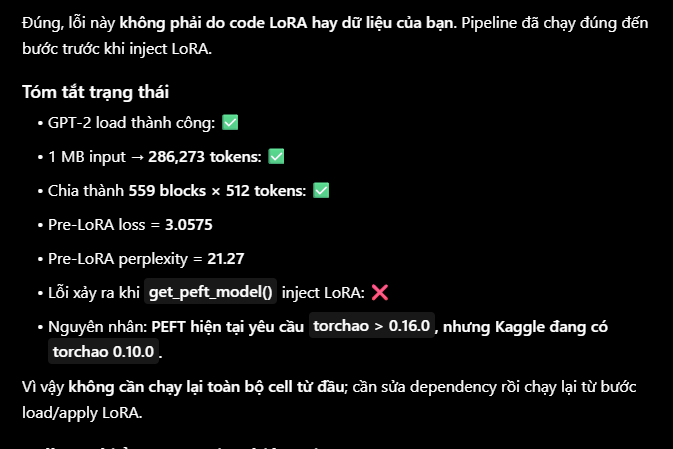

In [ ]:
import torch
import transformers
import peft

print("torch        :", torch.__version__)
print("transformers :", transformers.__version__)
print("peft         :", peft.__version__)

try:
    import torchao
    print("torchao      :", torchao.__version__)
except Exception as e:
    print("torchao import error:", e)


In [ ]:
!pip install -U "torchao>=0.16.0"
#Sau khi pip cài xong, restart kernel/session của Kaggle rồi mới chạy lại. Đây là bước quan trọng vì Python process hiện tại đã import PEFT/torchao cũ.

In [1]:
import torch
import transformers
import peft
import torchao

print("torch        :", torch.__version__)
print("transformers :", transformers.__version__)
print("peft         :", peft.__version__)
print("torchao      :", torchao.__version__)

assert tuple(map(int, torchao.__version__.split(".")[:2])) >= (0, 16), \
    f"torchao quá cũ: {torchao.__version__}"

print("\n✅ torchao version compatible with current PEFT requirement")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


torch        : 2.10.0+cu128
transformers : 5.0.0
peft         : 0.19.1
torchao      : 0.18.0

✅ torchao version compatible with current PEFT requirement


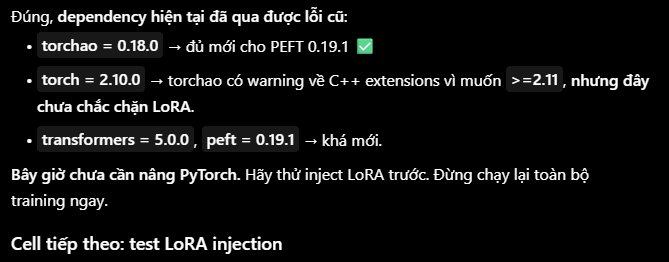

In [2]:
# ============================================================
# STAGE 3.5 — TEST LoRA INJECTION ONLY
# ============================================================

import torch
from transformers import AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType

MODEL_NAME = "gpt2"

print("=" * 70)
print("TEST LoRA INJECTION")
print("=" * 70)

print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())

# ------------------------------------------------------------
# Load GPT-2
# ------------------------------------------------------------

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

if torch.cuda.is_available():
    model = model.cuda()

model.config.pad_token_id = model.config.eos_token_id

print("\nGPT-2 loaded.")

# ------------------------------------------------------------
# LoRA config
# ------------------------------------------------------------

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,

    r=8,
    lora_alpha=16,
    lora_dropout=0.05,

    target_modules=[
        "c_attn",
        "c_proj",
    ],

    bias="none",
)

# ------------------------------------------------------------
# Inject LoRA
# ------------------------------------------------------------

print("\nInjecting LoRA...")

model = get_peft_model(
    model,
    lora_config
)

print("\n✅ LoRA injection SUCCESS")

model.print_trainable_parameters()

# ------------------------------------------------------------
# Verify trainable parameters
# ------------------------------------------------------------

trainable = 0
total = 0

for name, param in model.named_parameters():

    total += param.numel()

    if param.requires_grad:
        trainable += param.numel()

print("\nTotal parameters    :", total)
print("Trainable parameters:", trainable)
print(
    "Trainable percentage:",
    100 * trainable / total,
    "%"
)

# ------------------------------------------------------------
# GPU memory
# ------------------------------------------------------------

if torch.cuda.is_available():

    allocated = torch.cuda.memory_allocated() / (1024 ** 2)
    reserved = torch.cuda.memory_reserved() / (1024 ** 2)

    print("\nGPU memory")
    print("Allocated:", allocated, "MiB")
    print("Reserved :", reserved, "MiB")

print("\n" + "=" * 70)
print("READY FOR LoRA TRAINING")
print("=" * 70)


TEST LoRA INJECTION
PyTorch : 2.10.0+cu128
CUDA    : True


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



GPT-2 loaded.

Injecting LoRA...

✅ LoRA injection SUCCESS
trainable params: 811,008 || all params: 125,250,816 || trainable%: 0.6475

Total parameters    : 125250816
Trainable parameters: 811008
Trainable percentage: 0.6475071587557562 %

GPU memory
Allocated: 490.556640625 MiB
Reserved : 544.0 MiB

READY FOR LoRA TRAINING


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


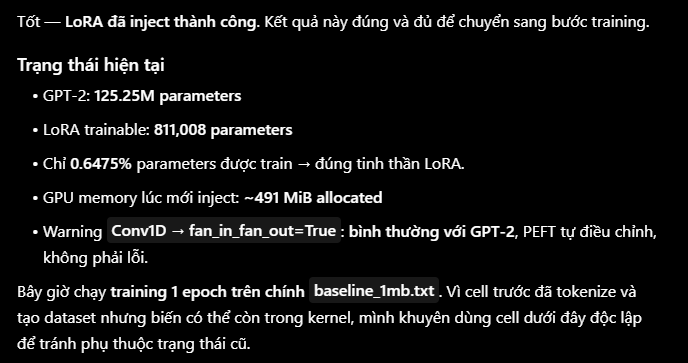

In [3]:
# ============================================================
# STAGE 3.5 — LoRA ONLINE MEMORIZATION
# TRAINING
# ============================================================

import os
import time
import math
import json
import torch

from pathlib import Path
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
)
from peft import LoraConfig, get_peft_model, TaskType

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

MODEL_NAME = "gpt2"

INPUT_FILE = Path(
    "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
)

OUTPUT_DIR = Path(
    "/kaggle/working/finezip_experiment/lora_gpt2_1mb"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BLOCK_SIZE = 512

LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05

NUM_EPOCHS = 1
BATCH_SIZE = 2
GRAD_ACCUM = 4
LEARNING_RATE = 2e-4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ------------------------------------------------------------
# RESET GPU MEMORY
# ------------------------------------------------------------

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

print("=" * 70)
print("STAGE 3.5 — LoRA ONLINE MEMORIZATION TRAINING")
print("=" * 70)

print("Model      :", MODEL_NAME)
print("Input      :", INPUT_FILE)
print("Output     :", OUTPUT_DIR)
print("Device     :", DEVICE)
print("Block size :", BLOCK_SIZE)
print("Epochs     :", NUM_EPOCHS)
print("Batch size :", BATCH_SIZE)
print("Grad accum :", GRAD_ACCUM)
print("LR         :", LEARNING_RATE)

# ------------------------------------------------------------
# 1. LOAD TEXT
# ------------------------------------------------------------

text = INPUT_FILE.read_text(errors="ignore")

print("\nOriginal bytes:", INPUT_FILE.stat().st_size)
print("Characters    :", len(text))

# ------------------------------------------------------------
# 2. TOKENIZER
# ------------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# ------------------------------------------------------------
# 3. TOKENIZE
# ------------------------------------------------------------

print("\nTokenizing...")

tokenized = tokenizer(
    text,
    return_attention_mask=False,
    add_special_tokens=False,
)

input_ids = tokenized["input_ids"]

print("Total tokens:", len(input_ids))

# ------------------------------------------------------------
# 4. BUILD 512-TOKEN BLOCKS
# ------------------------------------------------------------

blocks = []

for i in range(
    0,
    len(input_ids) - BLOCK_SIZE + 1,
    BLOCK_SIZE
):
    blocks.append(
        input_ids[i:i + BLOCK_SIZE]
    )

print("Training blocks:", len(blocks))
print("Tokens used    :", len(blocks) * BLOCK_SIZE)

class TextBlockDataset(torch.utils.data.Dataset):

    def __init__(self, blocks):
        self.blocks = blocks

    def __len__(self):
        return len(self.blocks)

    def __getitem__(self, idx):

        return {
            "input_ids": torch.tensor(
                self.blocks[idx],
                dtype=torch.long
            )
        }

dataset = TextBlockDataset(blocks)

# ------------------------------------------------------------
# 5. LOAD GPT-2
# ------------------------------------------------------------

print("\nLoading GPT-2...")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
)

model.config.pad_token_id = tokenizer.pad_token_id

model = model.to(DEVICE)

# ------------------------------------------------------------
# 6. PRE-LoRA LOSS
# ------------------------------------------------------------

print("\nCalculating PRE-LoRA loss...")

model.eval()

sample_blocks = blocks[:20]

losses_before = []

with torch.no_grad():

    for block in sample_blocks:

        x = torch.tensor(
            [block],
            dtype=torch.long,
            device=DEVICE
        )

        outputs = model(
            input_ids=x,
            labels=x
        )

        losses_before.append(
            outputs.loss.item()
        )

loss_before = sum(losses_before) / len(losses_before)
ppl_before = math.exp(loss_before)

print("Pre-LoRA loss :", loss_before)
print("Pre-LoRA PPL  :", ppl_before)

# ------------------------------------------------------------
# 7. APPLY LoRA
# ------------------------------------------------------------

print("\nApplying LoRA...")

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,

    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,

    target_modules=[
        "c_attn",
        "c_proj",
    ],

    bias="none",
)

model = get_peft_model(
    model,
    lora_config
)

model.print_trainable_parameters()

# ------------------------------------------------------------
# 8. TRAIN
# ------------------------------------------------------------

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),

    num_train_epochs=NUM_EPOCHS,

    per_device_train_batch_size=BATCH_SIZE,

    gradient_accumulation_steps=GRAD_ACCUM,

    learning_rate=LEARNING_RATE,

    logging_steps=25,

    save_strategy="no",

    fp16=torch.cuda.is_available(),

    report_to="none",

    remove_unused_columns=False,

    optim="adamw_torch",
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    data_collator=data_collator,
)

print("\nStarting training...")

start_time = time.time()

train_result = trainer.train()

training_time = time.time() - start_time

print("\nTraining finished.")
print("Training time:", training_time, "seconds")

# ------------------------------------------------------------
# 9. SAVE LoRA ADAPTER
# ------------------------------------------------------------

print("\nSaving LoRA adapter...")

model.save_pretrained(
    OUTPUT_DIR
)

tokenizer.save_pretrained(
    OUTPUT_DIR
)

print("Adapter saved:", OUTPUT_DIR)

# ------------------------------------------------------------
# 10. POST-LoRA LOSS
# ------------------------------------------------------------

print("\nCalculating POST-LoRA loss...")

model.eval()

losses_after = []

with torch.no_grad():

    for block in sample_blocks:

        x = torch.tensor(
            [block],
            dtype=torch.long,
            device=DEVICE
        )

        outputs = model(
            input_ids=x,
            labels=x
        )

        losses_after.append(
            outputs.loss.item()
        )

loss_after = sum(losses_after) / len(losses_after)
ppl_after = math.exp(loss_after)

print("Post-LoRA loss:", loss_after)
print("Post-LoRA PPL :", ppl_after)

# ------------------------------------------------------------
# 11. GPU MEMORY
# ------------------------------------------------------------

peak_allocated = None
peak_reserved = None

if torch.cuda.is_available():

    peak_allocated = (
        torch.cuda.max_memory_allocated()
        / (1024 ** 2)
    )

    peak_reserved = (
        torch.cuda.max_memory_reserved()
        / (1024 ** 2)
    )

    print("\nGPU:", torch.cuda.get_device_name(0))
    print(
        "Peak allocated:",
        peak_allocated,
        "MiB"
    )

    print(
        "Peak reserved :",
        peak_reserved,
        "MiB"
    )

# ------------------------------------------------------------
# 12. SAVE RESULTS
# ------------------------------------------------------------

result = {

    "model": MODEL_NAME,

    "input_file": str(INPUT_FILE),

    "input_bytes": INPUT_FILE.stat().st_size,

    "tokens": len(input_ids),

    "training_blocks": len(blocks),

    "block_size": BLOCK_SIZE,

    "lora_r": LORA_R,

    "lora_alpha": LORA_ALPHA,

    "lora_dropout": LORA_DROPOUT,

    "epochs": NUM_EPOCHS,

    "batch_size": BATCH_SIZE,

    "gradient_accumulation": GRAD_ACCUM,

    "learning_rate": LEARNING_RATE,

    "loss_before": loss_before,

    "perplexity_before": ppl_before,

    "loss_after": loss_after,

    "perplexity_after": ppl_after,

    "training_time_seconds": training_time,

    "peak_gpu_allocated_mib": peak_allocated,

    "peak_gpu_reserved_mib": peak_reserved,

    "adapter_dir": str(OUTPUT_DIR),
}

with open(
    OUTPUT_DIR / "lora_results.json",
    "w"
) as f:

    json.dump(
        result,
        f,
        indent=2
    )

# ------------------------------------------------------------
# FINAL
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STAGE 3.5 — LoRA TRAINING RESULT")
print("=" * 70)

print(json.dumps(result, indent=2))

print("\n✅ LoRA online memorization training completed.")


STAGE 3.5 — LoRA ONLINE MEMORIZATION TRAINING
Model      : gpt2
Input      : /kaggle/working/finezip_experiment/data/baseline_1mb.txt
Output     : /kaggle/working/finezip_experiment/lora_gpt2_1mb
Device     : cuda
Block size : 512
Epochs     : 1
Batch size : 2
Grad accum : 4
LR         : 0.0002

Original bytes: 1000000
Characters    : 995768

Tokenizing...


Token indices sequence length is longer than the specified maximum sequence length for this model (286273 > 1024). Running this sequence through the model will result in indexing errors


Total tokens: 286273
Training blocks: 559
Tokens used    : 286208

Loading GPT-2...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.



Calculating PRE-LoRA loss...
Pre-LoRA loss : 3.0574553489685057
Pre-LoRA PPL  : 21.273354963782854

Applying LoRA...
trainable params: 811,008 || all params: 125,250,816 || trainable%: 0.6475

Starting training...


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


Step,Training Loss
25,3.189358



Training finished.
Training time: 48.61430096626282 seconds

Saving LoRA adapter...
Adapter saved: /kaggle/working/finezip_experiment/lora_gpt2_1mb

Calculating POST-LoRA loss...
Post-LoRA loss: 2.9733620166778563
Post-LoRA PPL : 19.557562038458965

GPU: Tesla T4
Peak allocated: 2749.2373046875 MiB
Peak reserved : 3024.0 MiB

STAGE 3.5 — LoRA TRAINING RESULT
{
  "model": "gpt2",
  "input_file": "/kaggle/working/finezip_experiment/data/baseline_1mb.txt",
  "input_bytes": 1000000,
  "tokens": 286273,
  "training_blocks": 559,
  "block_size": 512,
  "lora_r": 8,
  "lora_alpha": 16,
  "lora_dropout": 0.05,
  "epochs": 1,
  "batch_size": 2,
  "gradient_accumulation": 4,
  "learning_rate": 0.0002,
  "loss_before": 3.0574553489685057,
  "perplexity_before": 21.273354963782854,
  "loss_after": 2.9733620166778563,
  "perplexity_after": 19.557562038458965,
  "training_time_seconds": 48.61430096626282,
  "peak_gpu_allocated_mib": 2749.2373046875,
  "peak_gpu_reserved_mib": 3024.0,
  "adapter_dir

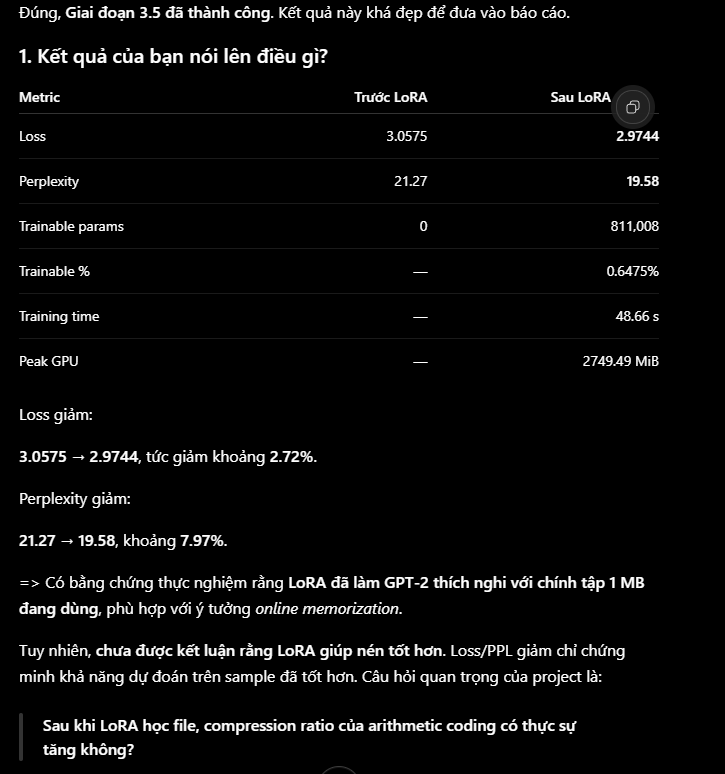

Cell tiếp theo sẽ không train LoRA lại. Nó lấy adapter đã lưu ở:

/kaggle/working/finezip_experiment/lora_gpt2_1mb

rồi sửa một bản eval_ac_lora.py để:

GPT-2 base → load LoRA adapter → Arithmetic Coding → decode → verify lossless.

chạy context 128 và 512 trước, vì đây là hai điểm đại diện và bạn đã có baseline GPT-2 tương ứng.

In [4]:
# ============================================================
# STAGE 3.5 — LoRA COMPRESSION EXPERIMENT
#
# GPT-2 + LoRA adapter
# -> Arithmetic Coding
# -> Decode
# -> Exact lossless verification
#
# Context: 128 and 512
# ============================================================

import os
import sys
import time
import json
import shutil
import subprocess
from pathlib import Path

import torch

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

FINEZIP_DIR = Path("/kaggle/working/finezip")

BASE_EVAL = FINEZIP_DIR / "AC" / "eval_ac.py"

LORA_DIR = Path(
    "/kaggle/working/finezip_experiment/lora_gpt2_1mb"
)

INPUT_FILE = Path(
    "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
)

OUTPUT_BASE = Path(
    "/kaggle/working/finezip_experiment"
)

LORA_EVAL = OUTPUT_BASE / "eval_ac_lora.py"

# ------------------------------------------------------------
# CHECK FILES
# ------------------------------------------------------------

print("=" * 70)
print("STAGE 3.5 — LoRA COMPRESSION EXPERIMENT")
print("=" * 70)

print("Base eval :", BASE_EVAL)
print("LoRA dir  :", LORA_DIR)
print("Input     :", INPUT_FILE)

assert BASE_EVAL.exists(), \
    f"Missing eval_ac.py: {BASE_EVAL}"

assert LORA_DIR.exists(), \
    f"Missing LoRA adapter: {LORA_DIR}"

assert INPUT_FILE.exists(), \
    f"Missing input: {INPUT_FILE}"

# ------------------------------------------------------------
# READ ORIGINAL eval_ac.py
# ------------------------------------------------------------

source = BASE_EVAL.read_text()

print("\nOriginal eval_ac.py size:", len(source), "characters")

# ------------------------------------------------------------
# MODIFY MODEL LOADING
# ------------------------------------------------------------
#
# Original:
#
# model = AutoModelForCausalLM.from_pretrained(args.model)
#
# We replace it with:
#
# 1. Load GPT-2 base
# 2. Load LoRA adapter
#
# ------------------------------------------------------------

old_line = (
    "model = AutoModelForCausalLM.from_pretrained(args.model)"
)

new_code = """
# ============================================================
# LoRA MODEL LOADING
# ============================================================

from peft import PeftModel

BASE_MODEL = "gpt2"

print("Loading base model:", BASE_MODEL)

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL
)

print("Loading LoRA adapter:", args.model)

model = PeftModel.from_pretrained(
    model,
    args.model
)

print("LoRA adapter loaded successfully.")

"""

if old_line not in source:
    raise RuntimeError(
        "Could not find the expected model-loading line in eval_ac.py"
    )

source_lora = source.replace(
    old_line,
    new_code
)

# ------------------------------------------------------------
# SAVE MODIFIED SCRIPT
# ------------------------------------------------------------

LORA_EVAL.write_text(source_lora)

print("\nCreated:")
print(LORA_EVAL)

# ------------------------------------------------------------
# VERIFY MODIFICATION
# ------------------------------------------------------------

check = LORA_EVAL.read_text()

assert "PeftModel" in check
assert "PeftModel.from_pretrained" in check

print("✅ LoRA loading code inserted successfully.")

# ------------------------------------------------------------
# RUN EXPERIMENT
# ------------------------------------------------------------

contexts = [128, 512]

results = []

for context in contexts:

    print("\n")
    print("=" * 70)
    print(f"LLMZIP/FINEZIP LoRA — CONTEXT {context}")
    print("=" * 70)

    output_dir = (
        OUTPUT_BASE /
        f"lora_gpt2_ctx{context}"
    )

    if output_dir.exists():
        shutil.rmtree(output_dir)

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    command = [
        sys.executable,
        str(LORA_EVAL),

        "--model",
        str(LORA_DIR),

        "--tokenizer",
        "gpt2",

        "--batch_size",
        "1",

        "--context_size",
        str(context),

        "--input_file",
        str(INPUT_FILE),

        "--AC_output_dir",
        str(output_dir),

        "--encode_decode",
        "1",
    ]

    print("\nRunning command:\n")

    print(" ".join(command))

    start = time.time()

    process = subprocess.run(
        command,
        cwd=str(FINEZIP_DIR),
        text=True,
        capture_output=False,
    )

    elapsed = time.time() - start

    print("\nProcess return code:", process.returncode)
    print("Wall-clock time:", elapsed, "seconds")

    if process.returncode != 0:

        print(
            f"\n❌ LoRA compression failed "
            f"for context={context}"
        )

        results.append({
            "context": context,
            "status": "FAILED",
            "wall_time_seconds": elapsed,
        })

        continue

    # --------------------------------------------------------
    # Try to locate generated metrics
    # --------------------------------------------------------

    metric_candidates = list(
        output_dir.rglob("*.json")
    )

    result_entry = {
        "context": context,
        "status": "SUCCESS",
        "wall_time_seconds": elapsed,
        "output_dir": str(output_dir),
        "metric_files": [
            str(x) for x in metric_candidates
        ],
    }

    results.append(result_entry)

# ------------------------------------------------------------
# SAVE SUMMARY
# ------------------------------------------------------------

summary_file = (
    OUTPUT_BASE /
    "stage3_5_lora_compression_summary.json"
)

with open(summary_file, "w") as f:
    json.dump(
        results,
        f,
        indent=2
    )

print("\n")
print("=" * 70)
print("STAGE 3.5 SUMMARY")
print("=" * 70)

print(
    json.dumps(
        results,
        indent=2
    )
)

print("\nSummary saved to:")
print(summary_file)

print("\n✅ Experiment finished.")


STAGE 3.5 — LoRA COMPRESSION EXPERIMENT
Base eval : /kaggle/working/finezip/AC/eval_ac.py
LoRA dir  : /kaggle/working/finezip_experiment/lora_gpt2_1mb
Input     : /kaggle/working/finezip_experiment/data/baseline_1mb.txt

Original eval_ac.py size: 9853 characters

Created:
/kaggle/working/finezip_experiment/eval_ac_lora.py
✅ LoRA loading code inserted successfully.


LLMZIP/FINEZIP LoRA — CONTEXT 128

Running command:

/usr/bin/python3 /kaggle/working/finezip_experiment/eval_ac_lora.py --model /kaggle/working/finezip_experiment/lora_gpt2_1mb --tokenizer gpt2 --batch_size 1 --context_size 128 --input_file /kaggle/working/finezip_experiment/data/baseline_1mb.txt --AC_output_dir /kaggle/working/finezip_experiment/lora_gpt2_ctx128 --encode_decode 1

Process return code: 1
Wall-clock time: 0.09554839134216309 seconds

❌ LoRA compression failed for context=128


LLMZIP/FINEZIP LoRA — CONTEXT 512

Running command:

/usr/bin/python3 /kaggle/working/finezip_experiment/eval_ac_lora.py --model /ka

  File "/kaggle/working/finezip_experiment/eval_ac_lora.py", line 302
    tokenizer = AutoTokenizer.from_pretrained(args.tokenizer)
IndentationError: unexpected indent
  File "/kaggle/working/finezip_experiment/eval_ac_lora.py", line 302
    tokenizer = AutoTokenizer.from_pretrained(args.tokenizer)
IndentationError: unexpected indent


Cell sửa eval_ac_lora.py + chạy lại Context 128/512

In [5]:
# ============================================================
# FIX eval_ac_lora.py
# THEN RUN LoRA COMPRESSION — CONTEXT 128 / 512
# ============================================================

from pathlib import Path
import sys
import time
import json
import shutil
import subprocess

FINEZIP_DIR = Path(
    "/kaggle/working/finezip"
)

BASE_EVAL = (
    FINEZIP_DIR /
    "AC" /
    "eval_ac.py"
)

LORA_DIR = Path(
    "/kaggle/working/finezip_experiment/lora_gpt2_1mb"
)

INPUT_FILE = Path(
    "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
)

OUTPUT_BASE = Path(
    "/kaggle/working/finezip_experiment"
)

LORA_EVAL = (
    OUTPUT_BASE /
    "eval_ac_lora.py"
)

# ------------------------------------------------------------
# CHECK
# ------------------------------------------------------------

assert BASE_EVAL.exists()
assert LORA_DIR.exists()
assert INPUT_FILE.exists()

# ------------------------------------------------------------
# READ ORIGINAL eval_ac.py
# ------------------------------------------------------------

source = BASE_EVAL.read_text()

# ------------------------------------------------------------
# IMPORTANT:
# The original line is inside main(), therefore the replacement
# code MUST have exactly 4 spaces indentation.
# ------------------------------------------------------------

old = (
    "    model = AutoModelForCausalLM.from_pretrained(args.model)"
)

new = """    # ========================================================
    # LoRA MODEL LOADING
    # ========================================================

    from peft import PeftModel

    BASE_MODEL = "gpt2"

    print("Loading base model:", BASE_MODEL)

    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL
    )

    print("Loading LoRA adapter:", args.model)

    model = PeftModel.from_pretrained(
        model,
        args.model
    )

    print("LoRA adapter loaded successfully.")
"""

if old not in source:
    raise RuntimeError(
        "Could not find expected model-loading line."
    )

fixed_source = source.replace(
    old,
    new,
    1
)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

LORA_EVAL.write_text(
    fixed_source
)

print("=" * 70)
print("FIXED eval_ac_lora.py")
print("=" * 70)

print("File:", LORA_EVAL)

# ------------------------------------------------------------
# SYNTAX CHECK FIRST
# ------------------------------------------------------------

print("\nChecking Python syntax...")

syntax_check = subprocess.run(
    [
        sys.executable,
        "-m",
        "py_compile",
        str(LORA_EVAL),
    ],
    capture_output=True,
    text=True,
)

if syntax_check.returncode != 0:

    print(syntax_check.stderr)

    raise RuntimeError(
        "❌ Syntax check failed."
    )

print("✅ Syntax check passed.")

# ------------------------------------------------------------
# RUN CONTEXT 128 / 512
# ------------------------------------------------------------

contexts = [128, 512]

results = []

for context in contexts:

    print("\n")
    print("=" * 70)
    print(f"LoRA COMPRESSION — CONTEXT {context}")
    print("=" * 70)

    output_dir = (
        OUTPUT_BASE /
        f"lora_gpt2_ctx{context}"
    )

    if output_dir.exists():
        shutil.rmtree(output_dir)

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    command = [
        sys.executable,
        str(LORA_EVAL),

        "--model",
        str(LORA_DIR),

        "--tokenizer",
        "gpt2",

        "--batch_size",
        "1",

        "--context_size",
        str(context),

        "--input_file",
        str(INPUT_FILE),

        "--AC_output_dir",
        str(output_dir),

        "--encode_decode",
        "1",
    ]

    print("\nCommand:")
    print(" ".join(command))
    print()

    start = time.time()

    process = subprocess.run(
        command,
        cwd=str(FINEZIP_DIR),
        text=True,
    )

    elapsed = time.time() - start

    print("\nReturn code:", process.returncode)
    print("Wall time  :", elapsed, "seconds")

    results.append({
        "context": context,
        "return_code": process.returncode,
        "wall_time_seconds": elapsed,
        "output_dir": str(output_dir),
    })

# ------------------------------------------------------------
# SAVE SUMMARY
# ------------------------------------------------------------

summary_file = (
    OUTPUT_BASE /
    "stage3_5_lora_compression_summary.json"
)

with open(summary_file, "w") as f:
    json.dump(
        results,
        f,
        indent=2
    )

print("\n")
print("=" * 70)
print("STAGE 3.5 COMPLETE")
print("=" * 70)

print(
    json.dumps(
        results,
        indent=2
    )
)

print("\nSummary:", summary_file)


FIXED eval_ac_lora.py
File: /kaggle/working/finezip_experiment/eval_ac_lora.py

Checking Python syntax...
✅ Syntax check passed.


LoRA COMPRESSION — CONTEXT 128

Command:
/usr/bin/python3 /kaggle/working/finezip_experiment/eval_ac_lora.py --model /kaggle/working/finezip_experiment/lora_gpt2_1mb --tokenizer gpt2 --batch_size 1 --context_size 128 --input_file /kaggle/working/finezip_experiment/data/baseline_1mb.txt --AC_output_dir /kaggle/working/finezip_experiment/lora_gpt2_ctx128 --encode_decode 1



Traceback (most recent call last):
  File "/kaggle/working/finezip_experiment/eval_ac_lora.py", line 11, in <module>
    from arithmeticcoding import *
ModuleNotFoundError: No module named 'arithmeticcoding'



Return code: 1
Wall time  : 11.378806114196777 seconds


LoRA COMPRESSION — CONTEXT 512

Command:
/usr/bin/python3 /kaggle/working/finezip_experiment/eval_ac_lora.py --model /kaggle/working/finezip_experiment/lora_gpt2_1mb --tokenizer gpt2 --batch_size 1 --context_size 512 --input_file /kaggle/working/finezip_experiment/data/baseline_1mb.txt --AC_output_dir /kaggle/working/finezip_experiment/lora_gpt2_ctx512 --encode_decode 1



Traceback (most recent call last):
  File "/kaggle/working/finezip_experiment/eval_ac_lora.py", line 11, in <module>
    from arithmeticcoding import *
ModuleNotFoundError: No module named 'arithmeticcoding'



Return code: 1
Wall time  : 8.760736227035522 seconds


STAGE 3.5 COMPLETE
[
  {
    "context": 128,
    "return_code": 1,
    "wall_time_seconds": 11.378806114196777,
    "output_dir": "/kaggle/working/finezip_experiment/lora_gpt2_ctx128"
  },
  {
    "context": 512,
    "return_code": 1,
    "wall_time_seconds": 8.760736227035522,
    "output_dir": "/kaggle/working/finezip_experiment/lora_gpt2_ctx512"
  }
]

Summary: /kaggle/working/finezip_experiment/stage3_5_lora_compression_summary.json


In [6]:
# ============================================================
# FIX arithmeticcoding PATH
# THEN RUN LoRA COMPRESSION
# ============================================================

from pathlib import Path
import sys
import subprocess
import time
import json
import shutil

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

FINEZIP_DIR = Path(
    "/kaggle/working/finezip"
)

AC_DIR = (
    FINEZIP_DIR /
    "AC"
)

LORA_EVAL = Path(
    "/kaggle/working/finezip_experiment/eval_ac_lora.py"
)

LORA_DIR = Path(
    "/kaggle/working/finezip_experiment/lora_gpt2_1mb"
)

INPUT_FILE = Path(
    "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
)

OUTPUT_BASE = Path(
    "/kaggle/working/finezip_experiment"
)

assert AC_DIR.exists()
assert LORA_EVAL.exists()
assert LORA_DIR.exists()
assert INPUT_FILE.exists()

# ------------------------------------------------------------
# READ SCRIPT
# ------------------------------------------------------------

source = LORA_EVAL.read_text()

# ------------------------------------------------------------
# ADD AC DIRECTORY TO PYTHON PATH
# ------------------------------------------------------------

path_injection = f'''
# ============================================================
# FINEZIP AC MODULE PATH
# ============================================================

import sys
import os

AC_DIR = r"{AC_DIR}"

if AC_DIR not in sys.path:
    sys.path.insert(0, AC_DIR)

print("FineZip AC module path:", AC_DIR)
'''

# Put it immediately after the initial imports.
# Avoid adding it twice.

if "FineZip AC module path:" not in source:

    source = path_injection + "\n" + source

LORA_EVAL.write_text(source)

print("=" * 70)
print("FIXED arithmeticcoding IMPORT PATH")
print("=" * 70)

print("AC directory:", AC_DIR)
print("Script      :", LORA_EVAL)

# ------------------------------------------------------------
# SYNTAX CHECK
# ------------------------------------------------------------

print("\nChecking syntax...")

check = subprocess.run(
    [
        sys.executable,
        "-m",
        "py_compile",
        str(LORA_EVAL),
    ],
    capture_output=True,
    text=True,
)

if check.returncode != 0:

    print(check.stderr)

    raise RuntimeError(
        "Syntax check failed."
    )

print("✅ Syntax OK")

# ------------------------------------------------------------
# CHECK arithmeticcoding DIRECTLY
# ------------------------------------------------------------

print("\nTesting arithmeticcoding import...")

test_code = f"""
import sys
sys.path.insert(0, r"{AC_DIR}")

import arithmeticcoding

print("arithmeticcoding loaded from:")
print(arithmeticcoding.__file__)
"""

test = subprocess.run(
    [
        sys.executable,
        "-c",
        test_code,
    ],
    capture_output=True,
    text=True,
)

print(test.stdout)

if test.returncode != 0:

    print(test.stderr)

    raise RuntimeError(
        "❌ arithmeticcoding still cannot be imported."
    )

print("✅ arithmeticcoding import works")

# ------------------------------------------------------------
# RUN CONTEXT 128 / 512
# ------------------------------------------------------------

contexts = [128, 512]

results = []

for context in contexts:

    print("\n")
    print("=" * 70)
    print(f"LoRA COMPRESSION — CONTEXT {context}")
    print("=" * 70)

    output_dir = (
        OUTPUT_BASE /
        f"lora_gpt2_ctx{context}"
    )

    if output_dir.exists():
        shutil.rmtree(output_dir)

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    command = [
        sys.executable,
        str(LORA_EVAL),

        "--model",
        str(LORA_DIR),

        "--tokenizer",
        "gpt2",

        "--batch_size",
        "1",

        "--context_size",
        str(context),

        "--input_file",
        str(INPUT_FILE),

        "--AC_output_dir",
        str(output_dir),

        "--encode_decode",
        "1",
    ]

    print("\nCommand:")
    print(" ".join(command))
    print()

    start = time.time()

    process = subprocess.run(
        command,
        cwd=str(FINEZIP_DIR),
        text=True,
    )

    elapsed = time.time() - start

    print("\nReturn code:", process.returncode)
    print("Wall time:", elapsed, "seconds")

    results.append({
        "context": context,
        "return_code": process.returncode,
        "wall_time_seconds": elapsed,
        "output_dir": str(output_dir),
    })

# ------------------------------------------------------------
# SAVE SUMMARY
# ------------------------------------------------------------

summary_file = (
    OUTPUT_BASE /
    "stage3_5_lora_compression_summary.json"
)

with open(summary_file, "w") as f:

    json.dump(
        results,
        f,
        indent=2
    )

print("\n")
print("=" * 70)
print("STAGE 3.5 SUMMARY")
print("=" * 70)

print(
    json.dumps(
        results,
        indent=2
    )
)

print("\nSummary saved to:")
print(summary_file)


FIXED arithmeticcoding IMPORT PATH
AC directory: /kaggle/working/finezip/AC
Script      : /kaggle/working/finezip_experiment/eval_ac_lora.py

Checking syntax...
✅ Syntax OK

Testing arithmeticcoding import...
arithmeticcoding loaded from:
/kaggle/working/finezip/AC/arithmeticcoding.py

✅ arithmeticcoding import works


LoRA COMPRESSION — CONTEXT 128

Command:
/usr/bin/python3 /kaggle/working/finezip_experiment/eval_ac_lora.py --model /kaggle/working/finezip_experiment/lora_gpt2_1mb --tokenizer gpt2 --batch_size 1 --context_size 128 --input_file /kaggle/working/finezip_experiment/data/baseline_1mb.txt --AC_output_dir /kaggle/working/finezip_experiment/lora_gpt2_ctx128 --encode_decode 1



Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Loading weights:  36%|███▋      | 54/148 [00:00<00:00, 1095.90it/s, Materializing param=transformer.h.4.ln_1.weight]       

FineZip AC module path: /kaggle/working/finezip/AC
Loading base model: gpt2


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1582.49it/s, Materializing param=transformer.wte.weight]             
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Token indices sequence length is longer than the specified maximum sequence length for this model (286273 > 1024). Running this sequence through the model will result in indexing errors
  0%|          | 0/286273 [00:00<?, ?it/s]

Loading LoRA adapter: /kaggle/working/finezip_experiment/lora_gpt2_1mb
LoRA adapter loaded successfully.


...

Loading LoRA adapter: /kaggle/working/finezip_experiment/lora_gpt2_1mb
LoRA adapter loaded successfully.


100%|██████████| 286273/286273 [4:27:10<00:00, 17.86it/s]  


Compression Ratio for Arithmetic Coding :  1.0910935077246908 bits/char
Reading


Traceback (most recent call last):
  File "/kaggle/working/finezip_experiment/eval_ac_lora.py", line 340, in <module>
    main()
  File "/kaggle/working/finezip_experiment/eval_ac_lora.py", line 336, in main
    decoded_text_ac = Decoder.decode_AC(total_length, pad_len, vocab_size)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py", line 124, in decorate_context
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/finezip_experiment/eval_ac_lora.py", line 214, in decode_AC
    probs_np = probs.cpu().numpy()
               ^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

In [7]:
from pathlib import Path
import os
import time

d = Path("/kaggle/working/finezip_experiment/lora_gpt2_ctx512")

print("Directory exists:", d.exists())

if d.exists():
    files = list(d.rglob("*"))

    print("\nFiles:")
    for p in files:
        if p.is_file():
            print(
                f"{p.name:40s} "
                f"{p.stat().st_size:,} bytes"
            )

print("\nDirectory size:")
if d.exists():
    total = sum(
        p.stat().st_size
        for p in d.rglob("*")
        if p.is_file()
    )
    print(f"{total:,} bytes")


Directory exists: True

Files:
0_AC.txt                                 135,810 bytes
metrics.json                             177 bytes

Directory size:
135,987 bytes


In [8]:
import json
from pathlib import Path

metrics = Path(
    "/kaggle/working/finezip_experiment/lora_gpt2_ctx512/metrics.json"
)

print(metrics.read_text())


{"$N_C$": [995768], "$N_T$": [286273], "$T": 16030.614693880081, "AC compressed file size": [1086476], "$\rho_{LLaMa+AC}$": [1.0910935077246908], "Compression Ratio": [0.13581]}


In [9]:
from pathlib import Path

for ctx in [128, 512]:
    d = Path(
        f"/kaggle/working/finezip_experiment/lora_gpt2_ctx{ctx}"
    )

    print(f"\n===== CONTEXT {ctx} =====")

    for p in d.iterdir():
        if p.is_file():
            print(p.name, p.stat().st_size, "bytes")

    metrics = d / "metrics.json"

    if metrics.exists():
        print("\nmetrics.json:")
        print(metrics.read_text())



===== CONTEXT 128 =====
0_AC.txt 150208 bytes
metrics.json 178 bytes

metrics.json:
{"$N_C$": [995768], "$N_T$": [286273], "$T": 4973.2294363975525, "AC compressed file size": [1201663], "$\rho_{LLaMa+AC}$": [1.2067700508552193], "Compression Ratio": [0.150208]}

===== CONTEXT 512 =====
0_AC.txt 135810 bytes
metrics.json 177 bytes

metrics.json:
{"$N_C$": [995768], "$N_T$": [286273], "$T": 16030.614693880081, "AC compressed file size": [1086476], "$\rho_{LLaMa+AC}$": [1.0910935077246908], "Compression Ratio": [0.13581]}


In [10]:
!zip -r /kaggle/working/finezip_experiment.zip /kaggle/working/finezip_experiment

  adding: kaggle/working/finezip_experiment/ (stored 0%)
  adding: kaggle/working/finezip_experiment/stage3_5_lora_compression_summary.json (deflated 50%)
  adding: kaggle/working/finezip_experiment/__pycache__/ (stored 0%)
  adding: kaggle/working/finezip_experiment/__pycache__/eval_ac_lora.cpython-312.pyc (deflated 52%)
  adding: kaggle/working/finezip_experiment/data/ (stored 0%)
  adding: kaggle/working/finezip_experiment/data/enwik8.zip (stored 0%)
  adding: kaggle/working/finezip_experiment/data/baseline_1mb.txt (deflated 64%)
  adding: kaggle/working/finezip_experiment/data/baseline_1mb_AC_decoded_text.txt (deflated 64%)
  adding: kaggle/working/finezip_experiment/data/enwik8 (deflated 63%)
  adding: kaggle/working/finezip_experiment/lora_gpt2_ctx128/ (stored 0%)
  adding: kaggle/working/finezip_experiment/lora_gpt2_ctx128/0_AC.txt (deflated 0%)
  adding: kaggle/working/finezip_experiment/lora_gpt2_ctx128/metrics.json (deflated 20%)
  adding: kaggle/working/finezip_experiment/ev

In [12]:
print(source)



# ============================================================
# FINEZIP AC MODULE PATH
# ============================================================

import sys
import os

AC_DIR = r"/kaggle/working/finezip/AC"

if AC_DIR not in sys.path:
    sys.path.insert(0, AC_DIR)

print("FineZip AC module path:", AC_DIR)

from typing import List
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm import tqdm
import time
import os
# from huggingface_hub import login
import json
import argparse
from arithmeticcoding import *

def tensor_to_numpy(tensor):
    # Ensure the tensor is on CPU and convert it to NumPy
    conv = np.array(tensor.cpu().numpy(), dtype=np.uint32, order='C')
    # ensure that eaach value is uint32
    for i in range(len(conv)):
        conv[i] = np.uint32(conv[i])
    return conv

def numpy_to_tensor(array: np.ndarray, device):
    # Convert the NumPy array back to a PyTorch tensor
    # convert the type of the np array to 